<a href="https://colab.research.google.com/github/waj-ha/child-safety-fars-analysis/blob/main/notebooks/20260531_FARS_Child_Safety_Analysis_v001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The `!pip install` command is used to install Python packages. The `!` at the beginning tells Colab to run the command as a shell command. In this example, `numpy` is the name of the package to be installed.

In [ ]:
common_data_science_libraries = [
    "numpy",        # Numerical operations
    "pandas",       # Data manipulation and analysis
    "matplotlib",   # Basic plotting
    "seaborn",      # Enhanced statistical data visualization
    "scipy",        # Scientific computing
    "scikit-learn", # Machine learning algorithms
    "statsmodels",  # Statistical modeling
    "bokeh",        # Interactive visualizations
    "plotly",       # Interactive visualizations
    "xgboost",      # Gradient boosting
    "lightgbm",     # Gradient boosting
    "tensorflow",   # Deep learning
    # "keras",        # Deep learning API (often included with TensorFlow)
    # "pytorch",    # Removed as it's not the correct package name for PyTorch
    "nltk",         # Natural Language Toolkit
    "spacy",        # Advanced NLP
    "beautifulsoup4",# Web scraping
    "requests",     # HTTP requests for web data
    "outliers"
]

# Install all listed libraries
!pip install {" ".join(common_data_science_libraries)}

# Installing PyTorch (torch) separately
# For CPU-only version (most common in Colab free tier if GPU is not assigned):
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# For CUDA version (if you have a GPU runtime assigned, check appropriate CUDA version from PyTorch website):
# Example for CUDA 12.1 (check PyTorch website for your specific CUDA version):
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt # Import pyplot for plotting functions
import seaborn as sns
import sklearn
import tensorflow as tf

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}") # Access version from the main module
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# You can add simple verification tests here if needed, for example:
# print(np.array([1, 2, 3]) + np.array([4, 5, 6]))
# print(pd.DataFrame({'A': [1, 2], 'B': [3, 4]}))

NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
TensorFlow version: 2.20.0


These libraries are essential tools for most data science workflows:

*   **NumPy**: Fundamental package for numerical computation, especially with arrays and matrices.
*   **Pandas**: Provides high-performance, easy-to-use data structures and data analysis tools (DataFrames).
*   **Matplotlib**: A comprehensive library for creating static, animated, and interactive visualizations.
*   **Seaborn**: Built on Matplotlib, it provides a high-level interface for drawing attractive and informative statistical graphics.
*   **SciPy**: Used for scientific and technical computing, offering modules for optimization, linear algebra, integration, interpolation, special functions, FFT, signal and image processing, and other tasks.
*   **Scikit-learn**: A robust machine learning library featuring various classification, regression, and clustering algorithms, along with tools for model selection and preprocessing.
*   **Statsmodels**: Provides classes and functions for the estimation of many different statistical models, as well as for conducting statistical tests and statistical data exploration.
*   **Bokeh & Plotly**: Libraries for creating interactive plots and dashboards.
*   **XGBoost & LightGBM**: Popular and highly efficient implementations of gradient boosting decision trees, often used for supervised learning tasks.
*   **TensorFlow & PyTorch**: Leading open-source machine learning frameworks for deep learning.
*   **Keras**: A high-level API for building and training deep learning models, often running on top of TensorFlow.
*   **NLTK (Natural Language Toolkit) & SpaCy**: Libraries for natural language processing tasks like tokenization, stemming, tagging, parsing, and named entity recognition.
*   **BeautifulSoup4 & Requests**: Tools for web scraping, allowing you to fetch and parse data from websites.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df_accident = pd.read_csv('/content/drive/MyDrive/ReDi_Project_FARS2024NationalCSV/FARS2024NationalCSV/accident.csv', dtype=str, low_memory=False)
df_person = pd.read_csv('/content/drive/MyDrive/ReDi_Project_FARS2024NationalCSV/FARS2024NationalCSV/person.csv', dtype=str, low_memory=False)
df_vehicle = pd.read_csv('/content/drive/MyDrive/ReDi_Project_FARS2024NationalCSV/FARS2024NationalCSV/vehicle.csv', dtype=str, low_memory=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Overview

YouYou have loaded three main datasets related to traffic accidents:

*   **`df_accident`**: This DataFrame contains accident-level information. It has `36297` rows and `80` columns. Each row likely represents a unique accident, with columns detailing various aspects of the crash.

*   **`df_person`**: This DataFrame contains person-level information involved in the accidents. It has `88326` rows and `126` columns. This dataset provides details about each person involved in the accidents recorded in `df_accident`.

*   **`df_vehicle`**: This DataFrame contains vehicle-level information involved in the accidents. It has `56011` rows and `201` columns. This dataset provides details about each vehicle involved in the accidents recorded in `df_accident`.

### Primary Key Identification

Given the structure of the FARS datasets, the primary keys are likely:

*   For **`df_accident`**: The `ST_CASE` column serves as the primary key, uniquely identifying each accident.

*   For **`df_person`**: A composite primary key consisting of `ST_CASE`, `VEH_NO` (Vehicle Number), and `PER_NO` (Person Number) would uniquely identify each person involved in a specific vehicle in a particular accident.

*   For **`df_vehicle`**: A composite primary key consisting of `ST_CASE` and `VEH_NO` would uniquely identify each vehicle involved in a particular accident.

# Mergeing_Datasets

### Merging Datasets

Based on the primary keys identified earlier, we can merge the three DataFrames to create a comprehensive dataset for analysis.

1.  **`df_accident` and `df_vehicle`**: These can be merged using `ST_CASE` as the common key.
2.  **Combined (accident-vehicle) and `df_person`**: This can then be merged using `ST_CASE` and `VEH_NO` as common keys.

In [ ]:
# Merge df_accident with df_vehicle on 'ST_CASE'
df_merged_accident_vehicle = pd.merge(df_accident, df_vehicle, on='ST_CASE', how='inner', suffixes=('_accident', '_vehicle'))

# Merge the result with df_person on 'ST_CASE' and 'VEH_NO'
df_fars_complete = pd.merge(df_merged_accident_vehicle, df_person, on=['ST_CASE', 'VEH_NO'], how='inner', suffixes=('_vehicle', '_person'))

# Display the first few rows of the merged DataFrame
display(df_fars_complete.head())

# Print the shape of the merged DataFrame to see the total rows and columns
print(f"Shape of the complete merged DataFrame: {df_fars_complete.shape}")

,STATE_accident,STATENAME_accident,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS_accident,PVH_INVL,PERSONS,PERMVIT,...,DEVTYPE,DEVTYPENAME,DEVMOTOR,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME
0,1,Alabama,10001,0,0,1,1,0,1,1,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
1,1,Alabama,10002,0,0,1,1,0,1,1,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
2,1,Alabama,10003,1,1,1,1,0,2,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
3,1,Alabama,10003,1,1,1,1,0,2,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
4,1,Alabama,10004,1,1,1,1,0,1,1,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)


Shape of the complete merged DataFrame: (78880, 404)


### Summary Statistics of Numerical Columns

Let's examine the summary statistics for the numerical columns in our merged `df_fars_complete` DataFrame. This will provide insights into the central tendency, dispersion, and shape of the distribution of each numerical feature.

In [ ]:
# Display summary statistics for numerical columns
display(df_fars_complete.describe())

,STATE_accident,STATENAME_accident,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS_accident,PVH_INVL,PERSONS,PERMVIT,...,DEVTYPE,DEVTYPENAME,DEVMOTOR,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME
count,78880,78880,78880,78880,78880,78880,78880,78880,78880,78880,...,78880,78880,78880,78880,78880,78880,78880,78880,78880,78880
unique,51,51,36264,12,14,14,14,10,28,28,...,1,1,1,1,1,1,5,5,10,10
top,48,Texas,480776,0,0,2,2,0,2,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
freq,8605,8605,59,66958,66520,37790,37709,76817,20127,20132,...,78880,78880,78880,78880,78880,78880,48179,48179,48179,48179


### Removing Duplicate Rows

It's a good practice to check for and remove duplicate rows in a DataFrame to ensure data integrity and avoid skewed analysis. We will drop duplicates based on all columns, assuming that a complete duplicate row signifies an erroneous entry.

In [ ]:
# Get the shape of the DataFrame before dropping duplicates
initial_rows = df_fars_complete.shape[0]
print(f"Shape of df_fars_complete before dropping duplicates: {df_fars_complete.shape}")

# Drop duplicate rows based on all columns
df_fars_complete.drop_duplicates(inplace=True)

# Get the shape of the DataFrame after dropping duplicates
final_rows = df_fars_complete.shape[0]
print(f"Shape of df_fars_complete after dropping duplicates: {df_fars_complete.shape}")

# Calculate and print the number of duplicates removed
num_duplicates_removed = initial_rows - final_rows
print(f"Number of duplicate rows removed: {num_duplicates_removed}")

Shape of df_fars_complete before dropping duplicates: (78880, 404)
Shape of df_fars_complete after dropping duplicates: (78880, 404)
Number of duplicate rows removed: 0


# AGE


### Distribution of Age

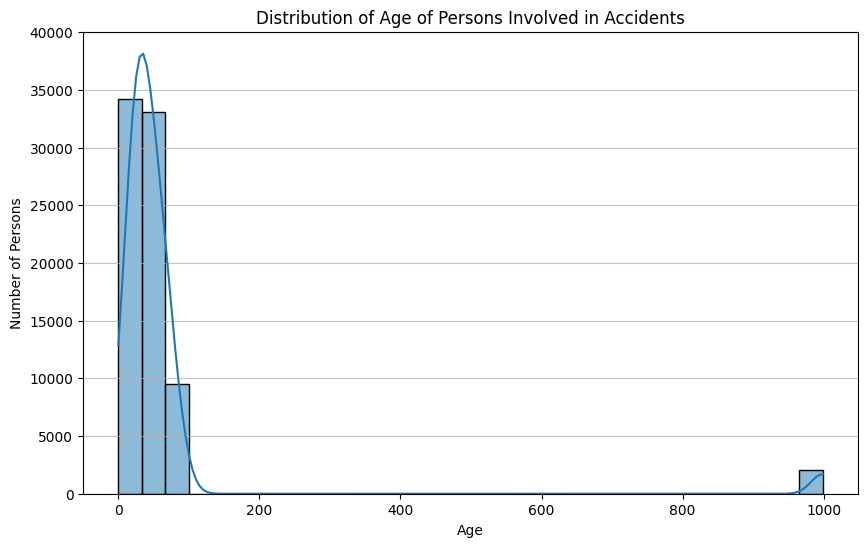

In [ ]:
# Convert 'AGE' column to numeric, coercing errors to NaN
df_fars_complete['AGE'] = pd.to_numeric(df_fars_complete['AGE'], errors='coerce')

# Drop rows where 'AGE' is NaN after conversion (if any)
df_fars_complete_age_cleaned = df_fars_complete.dropna(subset=['AGE'])

# Plotting the distribution of 'AGE'
plt.figure(figsize=(10, 6))
sns.histplot(df_fars_complete_age_cleaned['AGE'], bins=30, kde=True)
plt.title('Distribution of Age of Persons Involved in Accidents')
plt.xlabel('Age')
plt.ylabel('Number of Persons')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Outlier Removal from `AGE` Column

To further refine our analysis of the `AGE` column, I will remove outliers using the Interquartile Range (IQR) method. This method helps in identifying and excluding values that fall significantly outside the typical range of the data, providing a more robust distribution for analysis.

**Steps:**
1.  **Calculate Q1 and Q3:** Determine the 25th and 75th percentiles of the `AGE` data.
2.  **Calculate IQR:** Compute the Interquartile Range as the difference between Q3 and Q1.
3.  **Define Bounds:** Establish lower and upper bounds for outlier detection using the formula:
    *   Lower Bound = Q1 - 1.5 \* IQR
    *   Upper Bound = Q3 + 1.5 \* IQR
4.  **Filter Data:** Remove any rows where the `AGE` value falls below the lower bound or above the upper bound.

Number of outliers removed from AGE column: 2085
Shape of DataFrame after removing age outliers: (76795, 404)


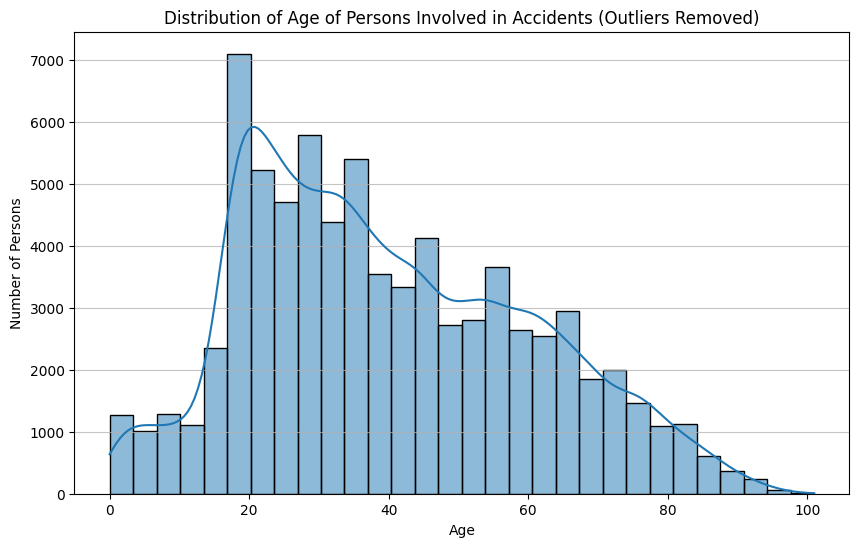

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_fars_complete_age_cleaned['AGE'].quantile(0.25)
Q3 = df_fars_complete_age_cleaned['AGE'].quantile(0.75)

# Calculate IQR (Interquartile Range)
IQR = Q3 - Q1

# Define lower and upper bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_fars_complete_age_no_outliers = df_fars_complete_age_cleaned[(df_fars_complete_age_cleaned['AGE'] >= lower_bound) & (df_fars_complete_age_cleaned['AGE'] <= upper_bound)]

# Calculate and print the number of outliers removed
num_outliers_removed = df_fars_complete_age_cleaned.shape[0] - df_fars_complete_age_no_outliers.shape[0]
print(f"Number of outliers removed from AGE column: {num_outliers_removed}")
print(f"Shape of DataFrame after removing age outliers: {df_fars_complete_age_no_outliers.shape}")

# Plotting the distribution of 'AGE' after outlier removal
plt.figure(figsize=(10, 6))
sns.histplot(df_fars_complete_age_no_outliers['AGE'], bins=30, kde=True)
plt.title('Distribution of Age of Persons Involved in Accidents (Outliers Removed)')
plt.xlabel('Age')
plt.ylabel('Number of Persons')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Age Group Distribution

To better understand the age demographics involved in accidents, we will categorize the `AGE` column into predefined age groups. This will allow for a more interpretable analysis of age-related patterns.

**Age Groups:**
*   Children (0-12)
*   Teens (13-19)
*   Young Adults (20-25)
*   Adults (26-35)
*   Middle Adults (36-45)
*   Mature Adults (46-55)
*   Older Adults (56-65)
*   Senior (66-75)
*   Elderly (76+)

In [ ]:
# Define custom bins and labels for age groups
custom_bins = [0, 13, 20, 26, 36, 46, 56, 66, 76, float('inf')]
custom_labels = [
    'Children (0-12)',
    'Teens (13-19)',
    'Young Adults (20-25)',
    'Adults (26-35)',
    'Middle Adults (36-45)',
    'Mature Adults (46-55)',
    'Older Adults (56-65)',
    'Senior (66-75)',
    'Elderly (76+)'
]

# Create a new column 'Custom_Age_Group' based on these bins
df_fars_complete_age_no_outliers.loc[:, 'Custom_Age_Group'] = pd.cut(
    df_fars_complete_age_no_outliers['AGE'],
    bins=custom_bins,
    labels=custom_labels,
    right=False # right=False means intervals are [a, b)
)

# Calculate counts and percentages for each custom age group
custom_age_group_counts = df_fars_complete_age_no_outliers['Custom_Age_Group'].value_counts().sort_index()
custom_age_group_percentages = (df_fars_complete_age_no_outliers['Custom_Age_Group'].value_counts(normalize=True) * 100).sort_index()

# Combine into a summary DataFrame, rounding percentages to 2 decimal places
age_group_summary = pd.DataFrame({
    'Count': custom_age_group_counts,
    'Percentage': custom_age_group_percentages.round(2)
})

print("Summary of Custom Age Groups:")
display(age_group_summary)

Summary of Custom Age Groups:


/tmp/ipykernel_1143/1294152262.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fars_complete_age_no_outliers.loc[:, 'Custom_Age_Group'] = pd.cut(


,Count,Percentage
Custom_Age_Group,,
Children (0-12),4268,5.56
Teens (13-19),8005,10.42
Young Adults (20-25),10286,13.39
Adults (26-35),14471,18.84
Middle Adults (36-45),11690,15.22
Mature Adults (46-55),9337,12.16
Older Adults (56-65),8520,11.09
Senior (66-75),5736,7.47
Elderly (76+),4482,5.84


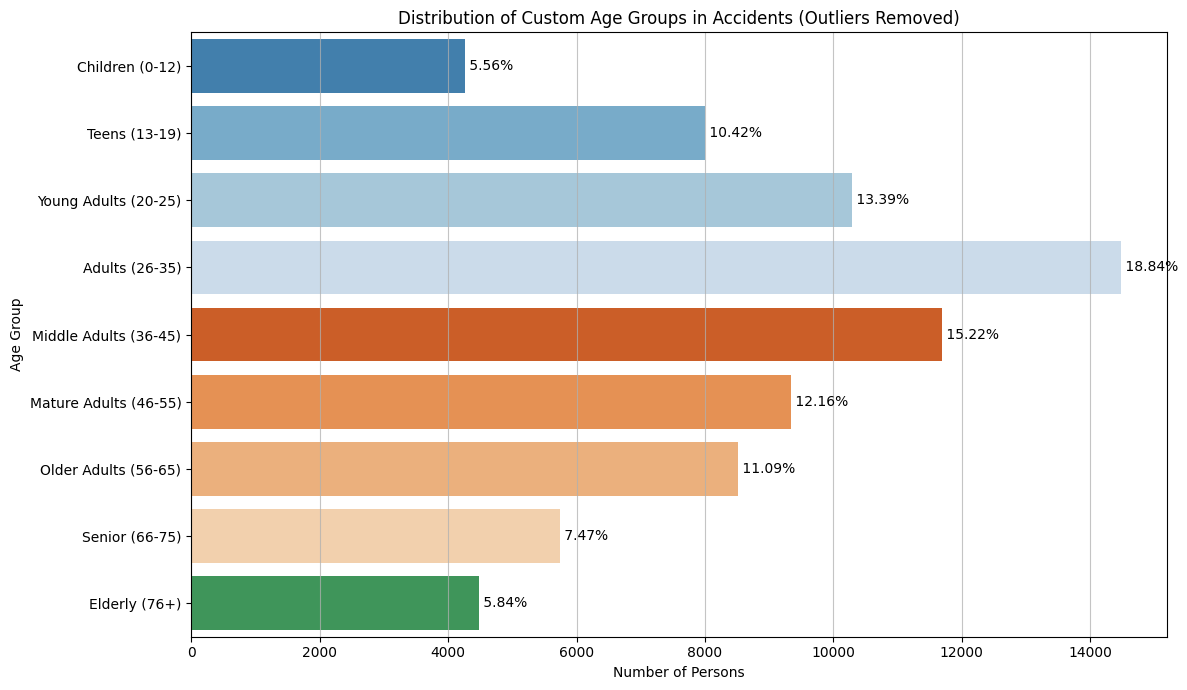

In [ ]:
# Plotting the distribution of custom age groups
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y=age_group_summary.index, data=age_group_summary, palette='tab20c', hue=age_group_summary.index, legend=False)
plt.title('Distribution of Custom Age Groups in Accidents (Outliers Removed)')
plt.xlabel('Number of Persons')
plt.ylabel('Age Group')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in age_group_summary.iterrows():
    plt.text(row['Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Distribution of `DEATHS` Column

To understand the frequency of different death counts in accidents, we will visualize the distribution of the `DEATHS` column. Since this column might contain non-numeric values due to initial loading as string, we will first convert it to a numeric type.

Shape of DataFrame after cleaning DEATHS column within age-filtered data: (76795, 405)


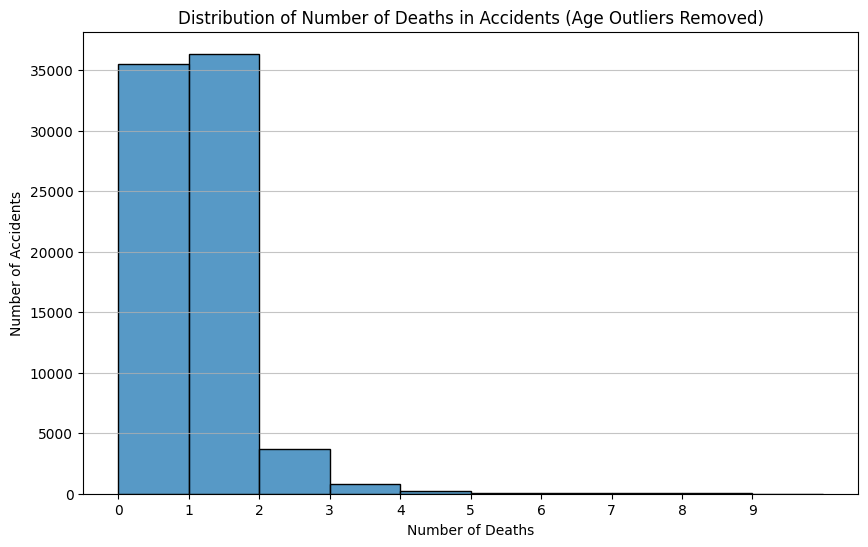

In [ ]:
# Convert 'DEATHS' column to numeric, coercing errors to NaN within the age-filtered DataFrame
df_fars_complete_age_no_outliers.loc[:, 'DEATHS'] = pd.to_numeric(df_fars_complete_age_no_outliers['DEATHS'], errors='coerce')

# Drop rows where 'DEATHS' is NaN after conversion (if any) from the age-filtered data
df_fars_complete_age_deaths_cleaned = df_fars_complete_age_no_outliers.dropna(subset=['DEATHS'])

print(f"Shape of DataFrame after cleaning DEATHS column within age-filtered data: {df_fars_complete_age_deaths_cleaned.shape}")

# Plotting the distribution of 'DEATHS' from the age-filtered and deaths-cleaned DataFrame
plt.figure(figsize=(10, 6))
sns.histplot(df_fars_complete_age_deaths_cleaned['DEATHS'], bins=range(int(df_fars_complete_age_deaths_cleaned['DEATHS'].min()), int(df_fars_complete_age_deaths_cleaned['DEATHS'].max()) + 2), kde=False, stat='count')
plt.title('Distribution of Number of Deaths in Accidents (Age Outliers Removed)')
plt.xlabel('Number of Deaths')
plt.ylabel('Number of Accidents')
plt.xticks(range(int(df_fars_complete_age_deaths_cleaned['DEATHS'].min()), int(df_fars_complete_age_deaths_cleaned['DEATHS'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

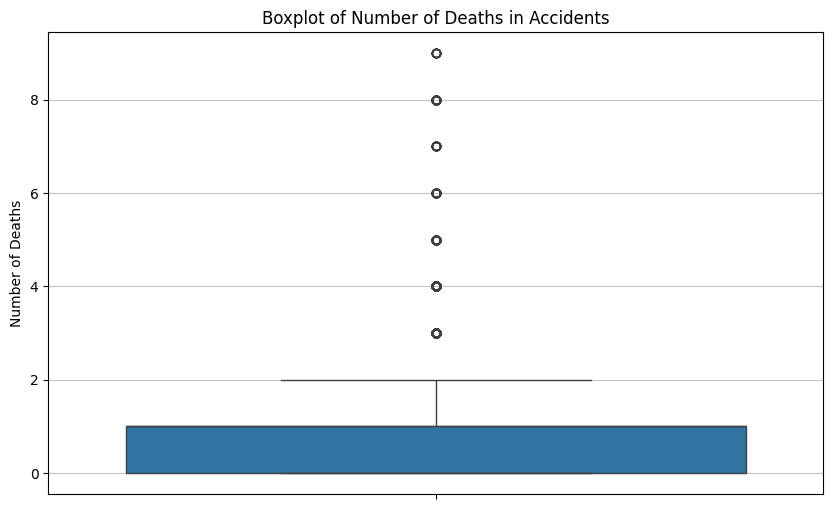

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_fars_complete_age_deaths_cleaned['DEATHS'])
plt.title('Boxplot of Number of Deaths in Accidents')
plt.ylabel('Number of Deaths')
plt.grid(axis='y', alpha=0.75)
plt.show()

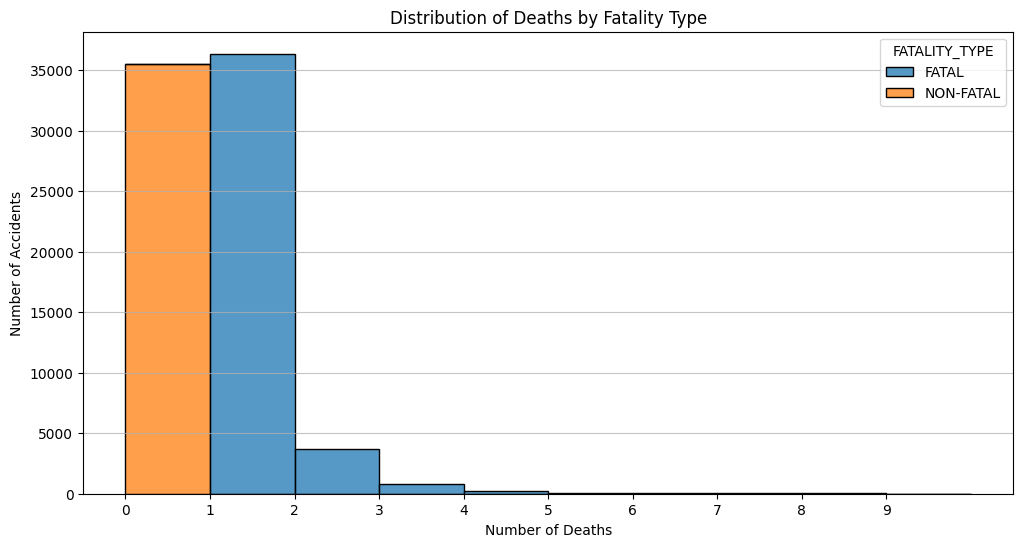

In [ ]:
df_fars_complete_age_deaths_cleaned.loc[:, 'FATALITY_TYPE'] = df_fars_complete_age_deaths_cleaned['DEATHS'].apply(lambda x: 'FATAL' if x > 0 else 'NON-FATAL')
plt.figure(figsize=(12, 6))
sns.histplot(data=df_fars_complete_age_deaths_cleaned, x='DEATHS', hue='FATALITY_TYPE', multiple='stack', bins=range(int(df_fars_complete_age_deaths_cleaned['DEATHS'].min()), int(df_fars_complete_age_deaths_cleaned['DEATHS'].max()) + 2), kde=False, stat='count')
plt.title('Distribution of Deaths by Fatality Type')
plt.xlabel('Number of Deaths')
plt.ylabel('Number of Accidents')
plt.xticks(range(int(df_fars_complete_age_deaths_cleaned['DEATHS'].min()), int(df_fars_complete_age_deaths_cleaned['DEATHS'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
fatality_counts = df_fars_complete_deaths_cleaned['FATALITY_TYPE'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(fatality_counts, labels=fatality_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Fatal vs. Non-Fatal Accidents')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

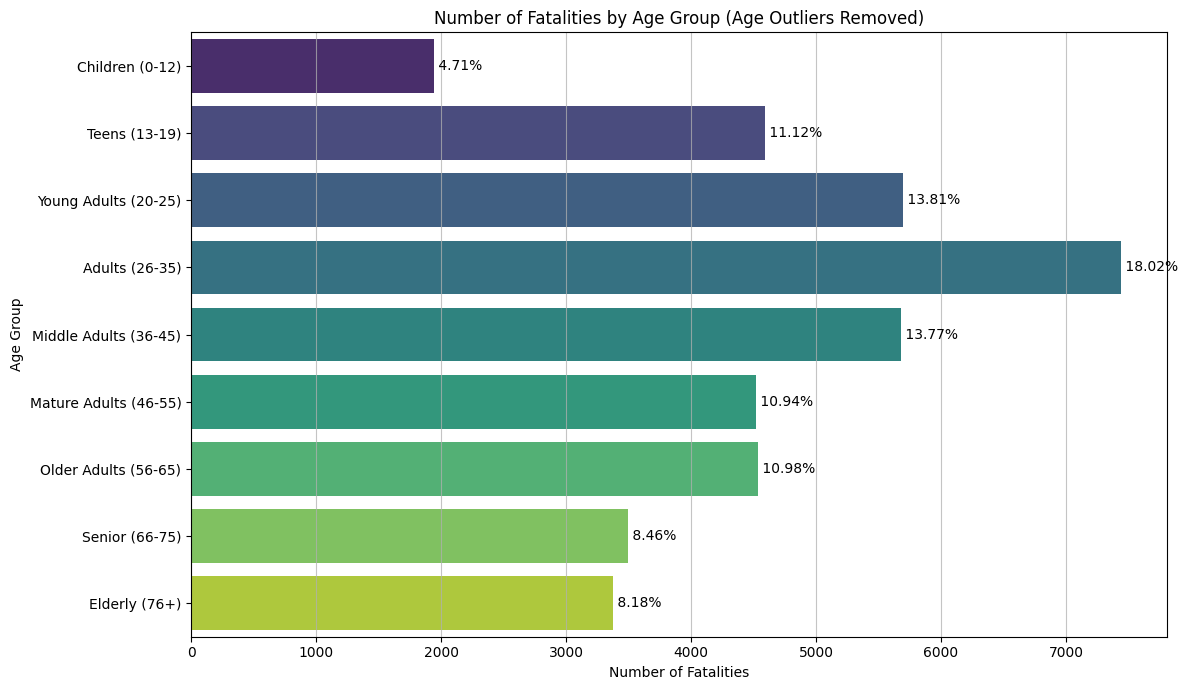


Table: Number of Fatalities by Age Group


,Custom_Age_Group,Fatal_Count,Percentage
0,Children (0-12),1944,4.709645
1,Teens (13-19),4592,11.124839
2,Young Adults (20-25),5700,13.809143
3,Adults (26-35),7438,18.019720
4,Middle Adults (36-45),5683,13.767958
5,Mature Adults (46-55),4516,10.940718
6,Older Adults (56-65),4533,10.981903
7,Senior (66-75),3494,8.464762
8,Elderly (76+),3377,8.181312



Total number of fatalities: 41277


In [ ]:
# Create 'FATALITY_TYPE' column in the appropriate DataFrame
df_fars_complete_age_deaths_cleaned.loc[:, 'FATALITY_TYPE'] = df_fars_complete_age_deaths_cleaned['DEATHS'].apply(lambda x: 'FATAL' if x > 0 else 'NON-FATAL')

# Group by Custom_Age_Group and FATALITY_TYPE to count fatal cases
fatalities_by_age_group = df_fars_complete_age_deaths_cleaned[df_fars_complete_age_deaths_cleaned['FATALITY_TYPE'] == 'FATAL'].groupby('Custom_Age_Group', observed=True).size().reset_index(name='Fatal_Count')

# Sort by Custom_Age_Group to maintain order
fatalities_by_age_group['Custom_Age_Group'] = pd.Categorical(
    fatalities_by_age_group['Custom_Age_Group'],
    categories=df_fars_complete_age_deaths_cleaned['Custom_Age_Group'].cat.categories,
    ordered=True
)
fatalities_by_age_group = fatalities_by_age_group.sort_values('Custom_Age_Group')

# Calculate percentages for annotation
total_fatalities = fatalities_by_age_group['Fatal_Count'].sum()
fatalities_by_age_group['Percentage'] = (fatalities_by_age_group['Fatal_Count'] / total_fatalities) * 100

plt.figure(figsize=(12, 7))
sns.barplot(x='Fatal_Count', y='Custom_Age_Group', data=fatalities_by_age_group, palette='viridis', hue='Custom_Age_Group', legend=False)
plt.title('Number of Fatalities by Age Group (Age Outliers Removed)')
plt.xlabel('Number of Fatalities')
plt.ylabel('Age Group')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in fatalities_by_age_group.iterrows():
    plt.text(row['Fatal_Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

print("\nTable: Number of Fatalities by Age Group")
display(fatalities_by_age_group)

print(f"\nTotal number of fatalities: {total_fatalities}")

### Fatalities by Children Sub-Age Group

To further dissect the impact on younger demographics, we will break down the 'Children (0-12)' age group into smaller subgroups and visualize their respective fatalities.


Table: Number of Fatalities by Children Sub-Age Group


,Children_Sub_Age_Group,Fatal_Count,Percentage
0,Infants (0-1),306,15.740741
1,Toddlers (2-3),287,14.763374
2,Preschoolers (4-5),355,18.261317
3,Young Children (6-9),565,29.063786
4,Pre-Teens (10-12),431,22.170782


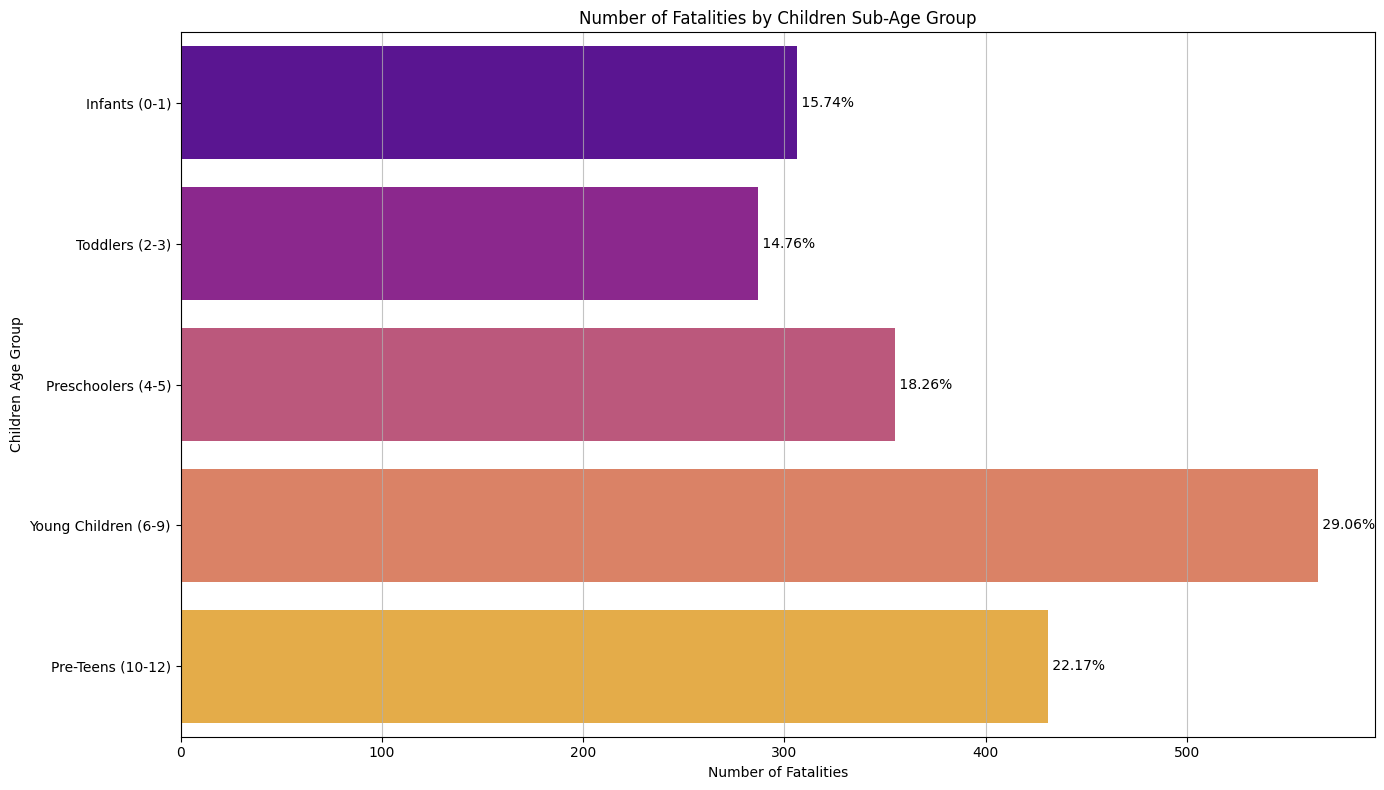

In [ ]:
# Filter for fatal cases within the 'Children (0-12)' age group
df_children_fatal = df_fars_complete_age_deaths_cleaned[
    (df_fars_complete_age_deaths_cleaned['Custom_Age_Group'] == 'Children (0-12)') &
    (df_fars_complete_age_deaths_cleaned['FATALITY_TYPE'] == 'FATAL')
].copy()

# Define custom bins and labels for children subgroups
children_custom_bins = [0, 2, 4, 6, 10, 13] # Age ranges: [0,2), [2,4), [4,6), [6,10), [10,13)
children_custom_labels = [
    'Infants (0-1)',
    'Toddlers (2-3)',
    'Preschoolers (4-5)',
    'Young Children (6-9)',
    'Pre-Teens (10-12)'
]

# Create a new column 'Children_Sub_Age_Group' within the filtered DataFrame
df_children_fatal.loc[:, 'Children_Sub_Age_Group'] = pd.cut(
    df_children_fatal['AGE'],
    bins=children_custom_bins,
    labels=children_custom_labels,
    right=False,
    ordered=True
)

# Calculate fatalities by children sub-age group
fatalities_by_children_subgroup = df_children_fatal.groupby('Children_Sub_Age_Group', observed=True).size().reset_index(name='Fatal_Count')

# Calculate percentages for annotation
total_children_fatalities = fatalities_by_children_subgroup['Fatal_Count'].sum()
fatalities_by_children_subgroup['Percentage'] = (fatalities_by_children_subgroup['Fatal_Count'] / total_children_fatalities) * 100

print("\nTable: Number of Fatalities by Children Sub-Age Group")
display(fatalities_by_children_subgroup)

# Plotting the distribution of fatalities by children sub-age group
plt.figure(figsize=(14, 8))
sns.barplot(x='Fatal_Count', y='Children_Sub_Age_Group', data=fatalities_by_children_subgroup, palette='plasma', hue='Children_Sub_Age_Group', legend=False)
plt.title('Number of Fatalities by Children Sub-Age Group')
plt.xlabel('Number of Fatalities')
plt.ylabel('Children Age Group')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in fatalities_by_children_subgroup.iterrows():
    plt.text(row['Fatal_Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

# Restraints

In [ ]:
df_fars_complete_age_deaths_cleaned.columns.tolist()

Summary of Restraint Use Categories:


,Count,Percentage
REST_USENAME,,
Shoulder and Lap Belt Used,43804,57.04
None Used/Not Applicable,23465,30.56
Reported as Unknown,6254,8.14
Child Restraint System - Forward Facing,627,0.82
Child Restraint Type Unknown,585,0.76
Not Reported,541,0.70
Lap Belt Only Used,458,0.60
Shoulder Belt Only Used,297,0.39
Child Restraint System - Rear Facing,267,0.35


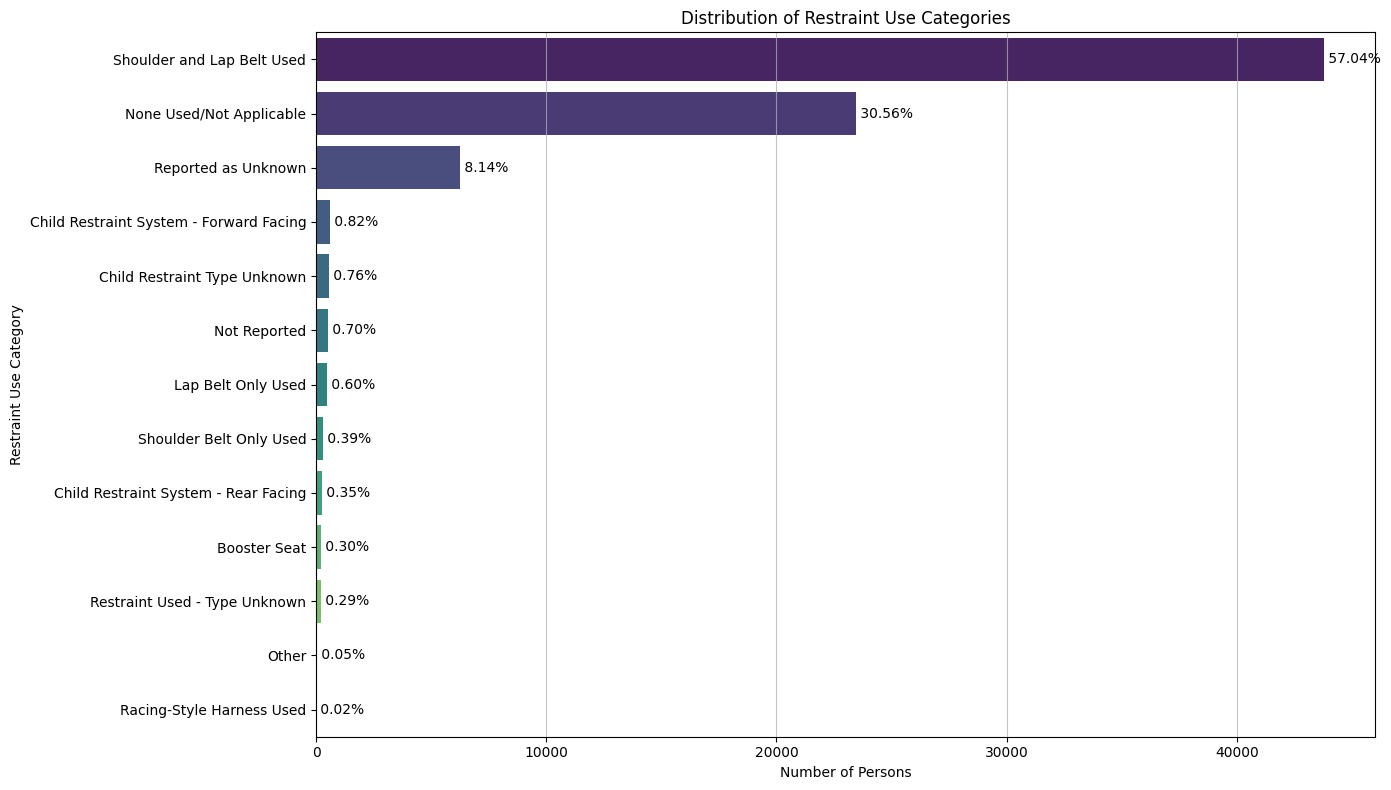

In [ ]:
# Calculate value counts and percentages for 'REST_USENAME'
rest_use_category_counts = df_fars_complete_age_deaths_cleaned['REST_USENAME'].value_counts()
rest_use_category_percentages = (df_fars_complete_age_deaths_cleaned['REST_USENAME'].value_counts(normalize=True) * 100).round(2)

# Combine into a summary DataFrame
rest_use_summary = pd.DataFrame({
    'Count': rest_use_category_counts,
    'Percentage': rest_use_category_percentages
})

print("Summary of Restraint Use Categories:")
display(rest_use_summary)

# Plotting the distribution of 'REST_USENAME' categories
plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y=rest_use_summary.index, data=rest_use_summary, palette='viridis', hue=rest_use_summary.index, legend=False)
plt.title('Distribution of Restraint Use Categories')
plt.xlabel('Number of Persons')
plt.ylabel('Restraint Use Category')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in rest_use_summary.iterrows():
    plt.text(row['Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Categorizing `REST_USE` into 'Restrained' and 'Not Restrained' (Revised)

Based on the analysis, we will refine the categorization of `REST_USE` into two primary groups:

*   **Restrained**: Includes individuals using specific restraint systems such as 'Lap Belt Only', 'Shoulder and Lap Belt Used', various 'Child Restraint Systems', 'Motorcycle Helmet', 'Other Helmet', and 'Restraint Used - Type Unknown'.
    *   Codes: `2, 3, 4, 6, 8, 10, 11, 12`
*   **Not Restrained**: Includes individuals who used 'None Used/Not Applicable', 'Shoulder Belt Only Used' (as per the revised categorization where `REST_USE` code '1' is considered 'Not Restrained' for this analysis), 'Reported as Unknown', 'Not Reported', and 'Other' categories.
    *   Codes: `1, 20, 97, 98, 99` (and any other unlisted codes)

This categorization aims to provide a more accurate representation of the impact of restraint use on accident outcomes.

In [ ]:
# Define the revised categorization for REST_USE codes
# Codes 2,3,4,6,8,10,11,12 are 'Restrained'
# All other codes (including 1 for 'Shoulder Belt Only Used') are 'Not Restrained'
restrained_codes_revised = ['2', '3', '4', '6', '8', '10', '11', '12']

# Create a copy to work with, using df_fars_complete_age_deaths_cleaned as base
df_categorized_restraints_revised = df_fars_complete_age_deaths_cleaned.copy()

# Apply the revised categorization
def categorize_restraint_status_revised(rest_use_code):
    rest_use_code_str = str(rest_use_code)
    if rest_use_code_str in restrained_codes_revised:
        return 'Restrained'
    else:
        return 'Not Restrained'

df_categorized_restraints_revised.loc[:, 'Restraint_Status_Final'] = df_categorized_restraints_revised['REST_USE'].apply(categorize_restraint_status_revised)

# Calculate counts and percentages for the new 'Restraint_Status_Final' column
final_restraint_status_counts = df_categorized_restraints_revised['Restraint_Status_Final'].value_counts()
final_restraint_status_percentages = (df_categorized_restraints_revised['Restraint_Status_Final'].value_counts(normalize=True) * 100).round(2)

final_restraint_status_summary = pd.DataFrame({
    'Count': final_restraint_status_counts,
    'Percentage': final_restraint_status_percentages
})

print("Overall Summary of Restraint Status by Revised Categories:")
display(final_restraint_status_summary)

Overall Summary of Restraint Status by Revised Categories:


,Count,Percentage
Restraint_Status_Final,,
Restrained,46203,60.16
Not Restrained,30592,39.84


### Visualization of Revised Restraint Status Distribution

Let's visualize the distribution of the newly defined 'Restrained' and 'Not Restrained' categories to understand their proportions in the dataset.

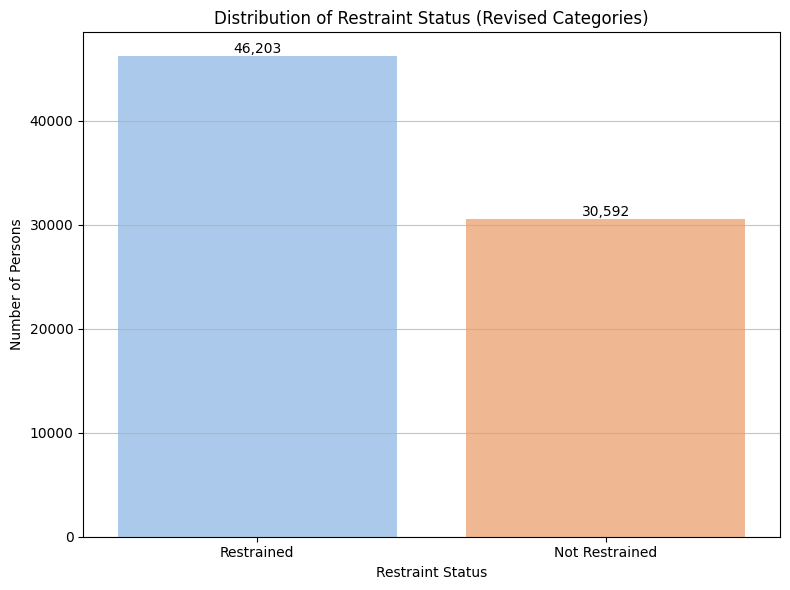

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=final_restraint_status_summary.index, y='Count', data=final_restraint_status_summary, palette='pastel', hue=final_restraint_status_summary.index, legend=False)
plt.title('Distribution of Restraint Status (Revised Categories)')
plt.xlabel('Restraint Status')
plt.ylabel('Number of Persons')
plt.grid(axis='y', alpha=0.75)

# Add count labels to the bars using ax.bar_label
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

### Fatalities by Revised Restraint Status

To understand the impact of restraint use on accident outcomes, let's analyze the number of fatalities for each of our newly defined 'Restrained' and 'Not Restrained' categories.

In [ ]:
# Filter for fatal cases based on the 'FATALITY_TYPE' column
fatal_cases_revised_cat = df_categorized_restraints_revised[df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL'].copy()

# Group by 'Restraint_Status_Final' and count fatalities
fatalities_by_revised_restraint_status = fatal_cases_revised_cat['Restraint_Status_Final'].value_counts().reset_index()
fatalities_by_revised_restraint_status.columns = ['Restraint_Status', 'Fatalities']

# Calculate percentages
total_fatalities_revised_cat = fatalities_by_revised_restraint_status['Fatalities'].sum()
fatalities_by_revised_restraint_status['Percentage'] = (fatalities_by_revised_restraint_status['Fatalities'] / total_fatalities_revised_cat * 100).round(2)

print("Summary of Fatalities by Revised Restraint Status:")
display(fatalities_by_revised_restraint_status)

Summary of Fatalities by Revised Restraint Status:


,Restraint_Status,Fatalities,Percentage
0,Not Restrained,24609,59.62
1,Restrained,16668,40.38


### Visualization of Fatalities by Revised Restraint Status

This bar plot provides a clear visual comparison of the number of fatalities between individuals who were 'Restrained' and 'Not Restrained'.

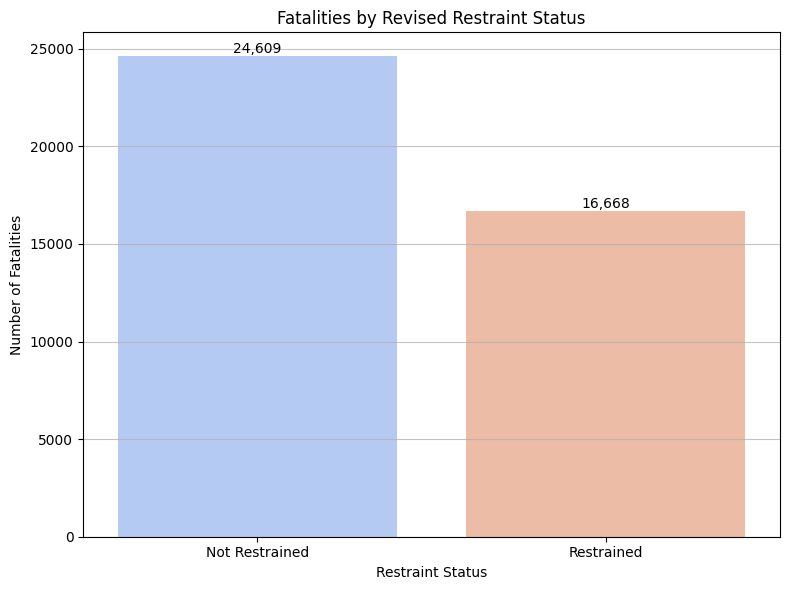

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Restraint_Status', y='Fatalities', data=fatalities_by_revised_restraint_status, palette='coolwarm', hue='Restraint_Status', legend=False)
plt.title('Fatalities by Revised Restraint Status')
plt.xlabel('Restraint Status')
plt.ylabel('Number of Fatalities')
plt.grid(axis='y', alpha=0.75)

# Add count labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

### Fatality Rates by Revised Restraint Status and Age Group

To gain deeper insights, let's analyze the fatality rates for 'Restrained' and 'Not Restrained' individuals across our defined age groups. This will highlight how restraint use impacts different demographics.

In [ ]:
import numpy as np

# Calculate total persons for each age group and restraint status
total_persons_by_age_restraint = df_categorized_restraints_revised.groupby(['Custom_Age_Group', 'Restraint_Status_Final'], observed=True).size().reset_index(name='Total_Persons')

# Calculate total fatalities for each age group and restraint status
fatalities_by_age_restraint = df_categorized_restraints_revised[df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL'].groupby(['Custom_Age_Group', 'Restraint_Status_Final'], observed=True).size().reset_index(name='Fatalities')

# Merge the two DataFrames
merged_data = pd.merge(total_persons_by_age_restraint, fatalities_by_age_restraint, on=['Custom_Age_Group', 'Restraint_Status_Final'], how='left')

# Fill NaN values in 'Fatalities' with 0 (for combinations with no fatalities)
merged_data['Fatalities'] = merged_data['Fatalities'].fillna(0).astype(int)

# Calculate Fatality Rate
merged_data['Fatality Rate (%)'] = (merged_data['Fatalities'] / merged_data['Total_Persons'] * 100).round(2)

print("Fatality Rates by Age Group and Restraint Status:")
display(merged_data)


Fatality Rates by Age Group and Restraint Status:


,Custom_Age_Group,Restraint_Status_Final,Total_Persons,Fatalities,Fatality Rate (%)
0,Children (0-12),Not Restrained,1031,761,73.81
1,Children (0-12),Restrained,3237,1183,36.55
2,Teens (13-19),Not Restrained,3562,2880,80.85
3,Teens (13-19),Restrained,4443,1712,38.53
4,Young Adults (20-25),Not Restrained,4938,3907,79.12
5,Young Adults (20-25),Restrained,5348,1793,33.53
6,Adults (26-35),Not Restrained,6578,5181,78.76
7,Adults (26-35),Restrained,7893,2257,28.59
8,Middle Adults (36-45),Not Restrained,4750,3746,78.86
9,Middle Adults (36-45),Restrained,6940,1937,27.91


### Visualization of Fatality Rates by Restraint Status and Age Group

<Figure size 1400x800 with 0 Axes>

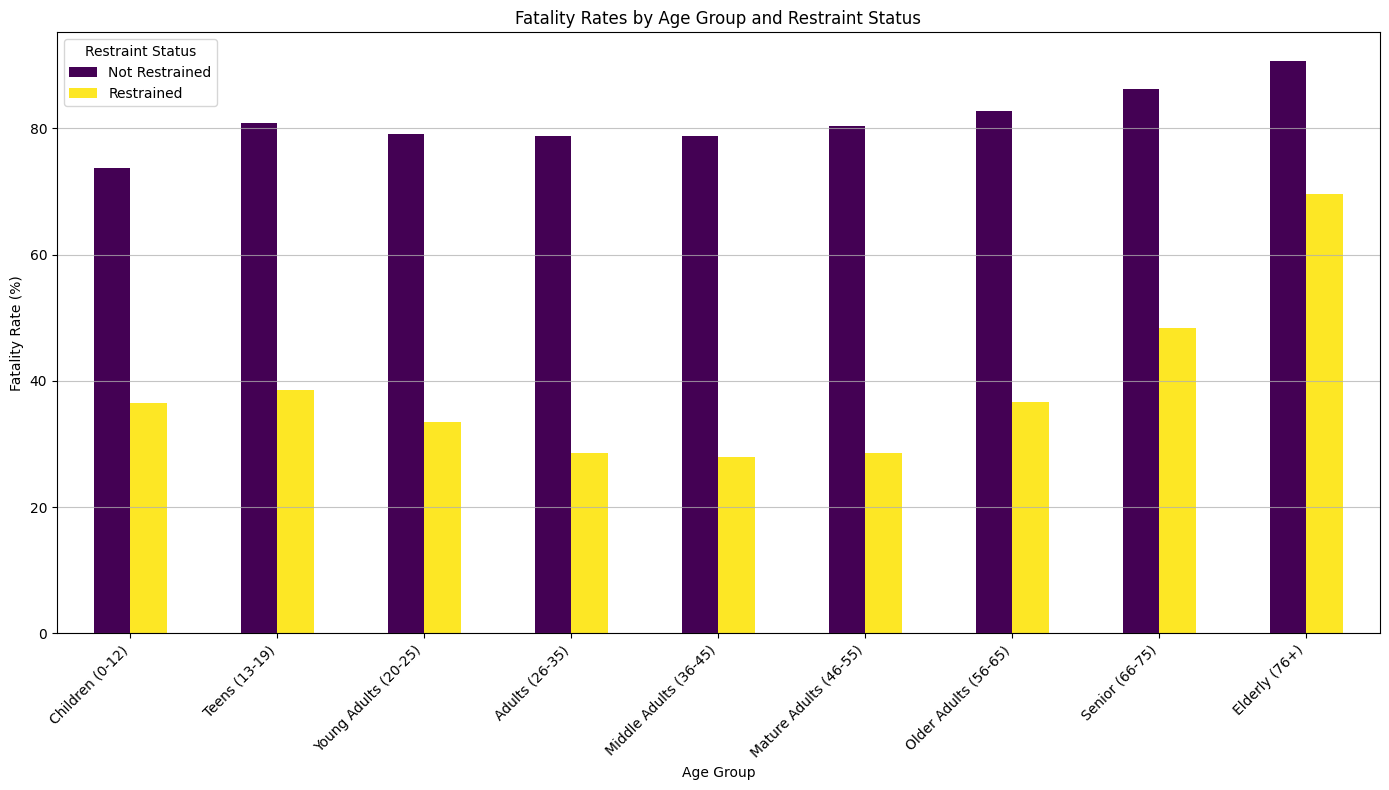

In [ ]:
# Create a pivot table for easier plotting
fatality_rates_pivot = merged_data.pivot(index='Custom_Age_Group', columns='Restraint_Status_Final', values='Fatality Rate (%)')

plt.figure(figsize=(14, 8))
fatality_rates_pivot.plot(kind='bar', figsize=(14, 8), colormap='viridis')
plt.title('Fatality Rates by Age Group and Restraint Status')
plt.xlabel('Age Group')
plt.ylabel('Fatality Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Restraint Status')
plt.tight_layout()
plt.show()


### Age Group with the Largest Impact from Restraint Use

Let's identify which age group shows the largest difference in fatality rates between 'Not Restrained' and 'Restrained' individuals. This could indicate where restraint use has the most significant protective effect.

In [ ]:
# Calculate the difference in fatality rates between 'Not Restrained' and 'Restrained'
fatality_rates_pivot['Rate_Difference'] = fatality_rates_pivot['Not Restrained'] - fatality_rates_pivot['Restrained']

# Find the age group with the largest difference
largest_impact_age_group = fatality_rates_pivot.loc[fatality_rates_pivot['Rate_Difference'].idxmax()]

print("Age Group with the Largest Impact (Largest Difference in Fatality Rates between Not Restrained and Restrained):")
display(largest_impact_age_group)


Age Group with the Largest Impact (Largest Difference in Fatality Rates between Not Restrained and Restrained):


,Mature Adults (46-55)
Restraint_Status_Final,
Not Restrained,80.40
Restrained,28.66
Rate_Difference,51.74


### Fatalities in Not Restrained Children Groups

Let's specifically examine the fatalities among 'Not Restrained' individuals within the 'Children (0-12)' age group. This will help us understand which child sub-age groups are most affected when not using restraints.


Table: Number of Fatalities in Not Restrained Children by Sub-Age Group


,Children_Sub_Age_Group,Fatal_Count,Percentage
0,Infants (0-1),61,8.02
1,Toddlers (2-3),95,12.48
2,Preschoolers (4-5),168,22.08
3,Young Children (6-9),237,31.14
4,Pre-Teens (10-12),200,26.28
5,Total,761,100.00


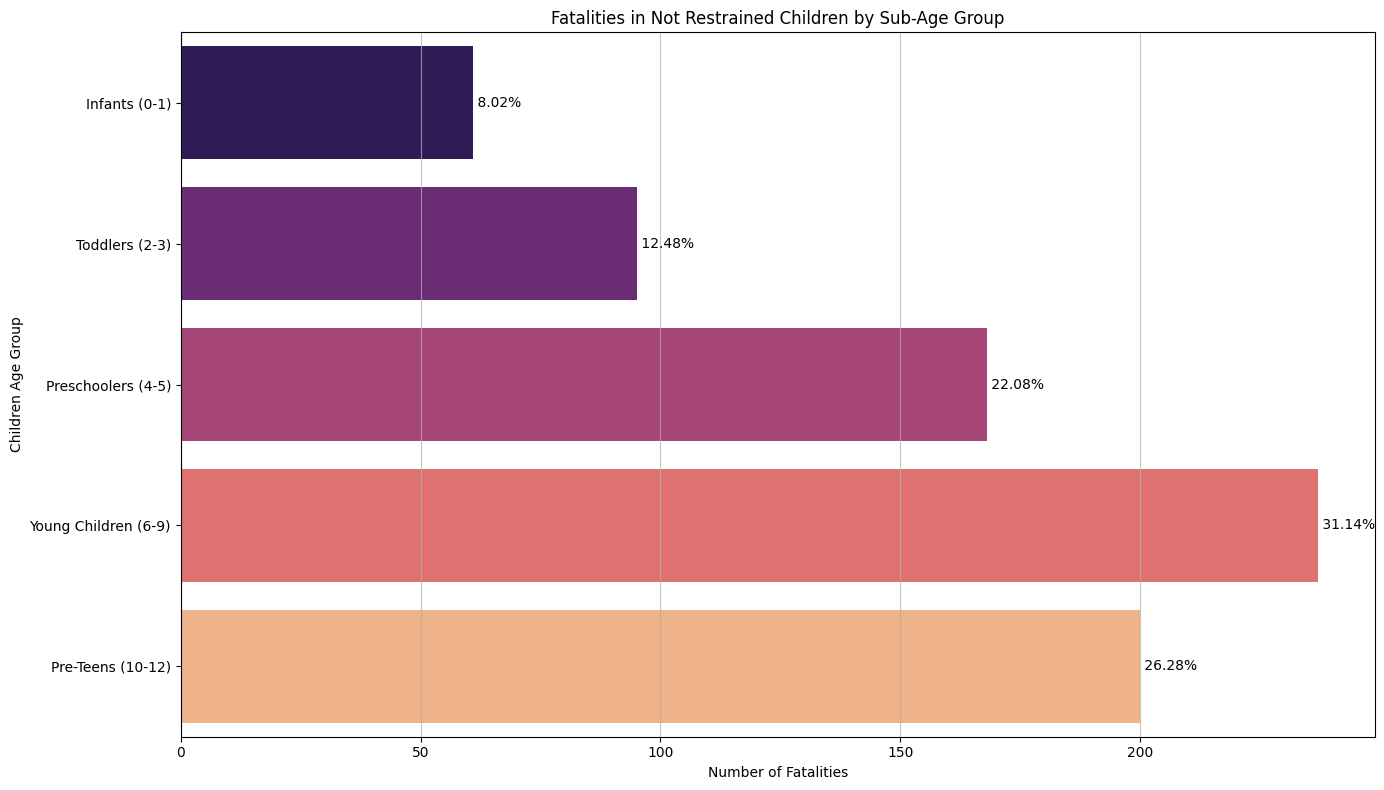

In [ ]:
# Filter for 'Not Restrained' and 'FATAL' cases within the 'Children (0-12)' age group
df_children_not_restrained_fatal = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['Restraint_Status_Final'] == 'Not Restrained') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL')
].copy()

# Define custom bins and labels for children subgroups (reusing definitions from earlier)
children_custom_bins = [0, 2, 4, 6, 10, 13] # Age ranges: [0,2), [2,4), [4,6), [6,10), [10,13)
children_custom_labels = [
    'Infants (0-1)',
    'Toddlers (2-3)',
    'Preschoolers (4-5)',
    'Young Children (6-9)',
    'Pre-Teens (10-12)'
]

# Create a new column 'Children_Sub_Age_Group' within the filtered DataFrame
df_children_not_restrained_fatal.loc[:, 'Children_Sub_Age_Group'] = pd.cut(
    df_children_not_restrained_fatal['AGE'],
    bins=children_custom_bins,
    labels=children_custom_labels,
    right=False,
    ordered=True
)

# Calculate fatalities by children sub-age group for 'Not Restrained' individuals
fatalities_by_children_not_restrained_subgroup = df_children_not_restrained_fatal.groupby('Children_Sub_Age_Group', observed=True).size().reset_index(name='Fatal_Count')

# Calculate percentages for annotation
total_children_not_restrained_fatalities = fatalities_by_children_not_restrained_subgroup['Fatal_Count'].sum()
fatalities_by_children_not_restrained_subgroup['Percentage'] = (fatalities_by_children_not_restrained_subgroup['Fatal_Count'] / total_children_not_restrained_fatalities * 100).round(2)

# Add a row for the total sum
total_row = pd.DataFrame([{'Children_Sub_Age_Group': 'Total', 'Fatal_Count': total_children_not_restrained_fatalities, 'Percentage': 100.00}])
fatalities_by_children_not_restrained_subgroup = pd.concat([fatalities_by_children_not_restrained_subgroup, total_row], ignore_index=True)

print("\nTable: Number of Fatalities in Not Restrained Children by Sub-Age Group")
display(fatalities_by_children_not_restrained_subgroup)

# Plotting the distribution of fatalities by children sub-age group for 'Not Restrained' individuals
plt.figure(figsize=(14, 8))
sns.barplot(x='Fatal_Count', y='Children_Sub_Age_Group', data=fatalities_by_children_not_restrained_subgroup.iloc[:-1], palette='magma', hue='Children_Sub_Age_Group', legend=False)
plt.title('Fatalities in Not Restrained Children by Sub-Age Group')
plt.xlabel('Number of Fatalities')
plt.ylabel('Children Age Group')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in fatalities_by_children_not_restrained_subgroup.iloc[:-1].iterrows():
    plt.text(row['Fatal_Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Fatalities in Restrained Children Groups

Now, let's specifically examine the fatalities among 'Restrained' individuals within the 'Children (0-12)' age group. This will help us understand which child sub-age groups are most affected even when using restraints.


Table: Number of Fatalities in Restrained Children by Sub-Age Group


,Children_Sub_Age_Group,Fatal_Count,Percentage
0,Infants (0-1),245,20.71
1,Toddlers (2-3),192,16.23
2,Preschoolers (4-5),187,15.81
3,Young Children (6-9),328,27.73
4,Pre-Teens (10-12),231,19.53
5,Total,1183,100.00


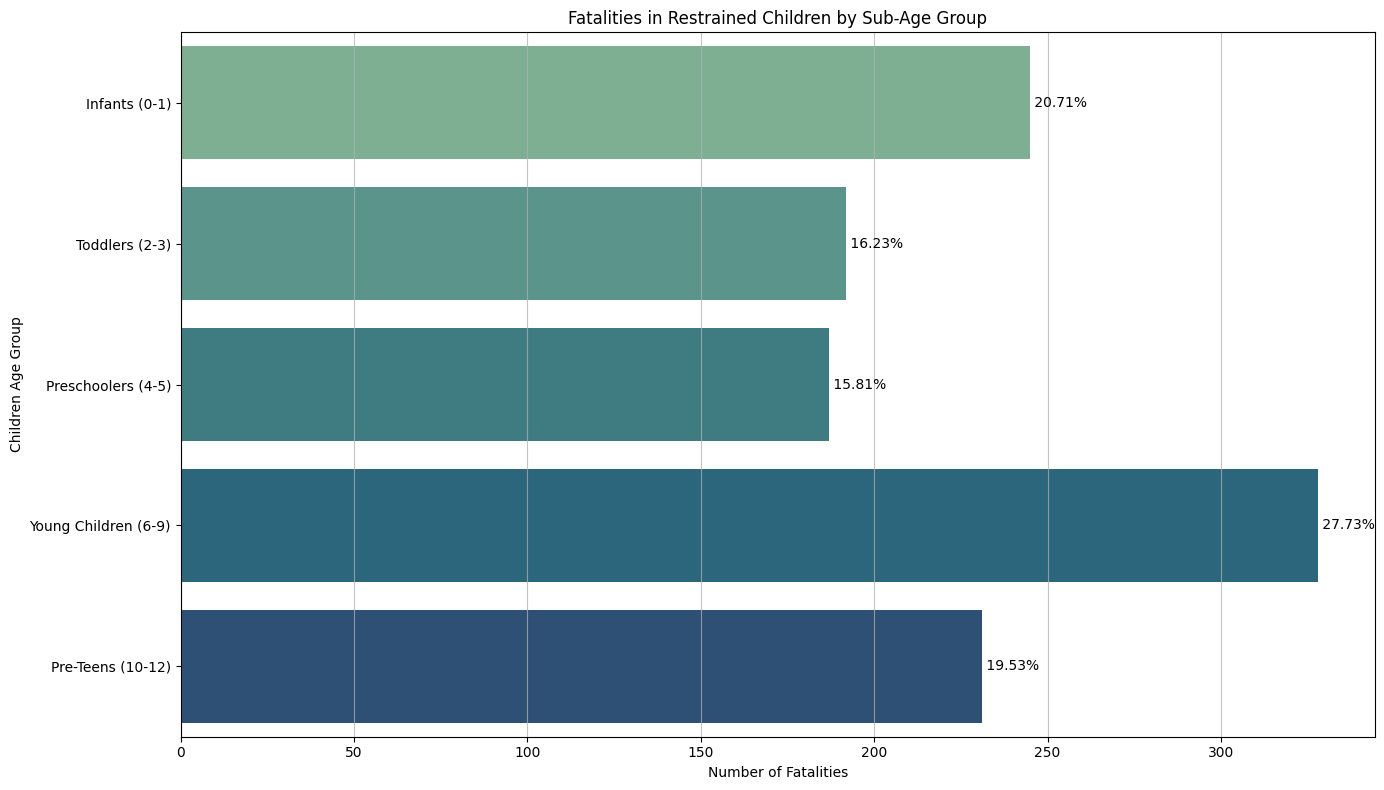

In [ ]:
# Filter for 'Restrained' and 'FATAL' cases within the 'Children (0-12)' age group
df_children_restrained_fatal = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['Restraint_Status_Final'] == 'Restrained') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL')
].copy()

# Define custom bins and labels for children subgroups (reusing definitions from earlier)
children_custom_bins = [0, 2, 4, 6, 10, 13] # Age ranges: [0,2), [2,4), [4,6), [6,10), [10,13)
children_custom_labels = [
    'Infants (0-1)',
    'Toddlers (2-3)',
    'Preschoolers (4-5)',
    'Young Children (6-9)',
    'Pre-Teens (10-12)'
]

# Create a new column 'Children_Sub_Age_Group' within the filtered DataFrame
df_children_restrained_fatal.loc[:, 'Children_Sub_Age_Group'] = pd.cut(
    df_children_restrained_fatal['AGE'],
    bins=children_custom_bins,
    labels=children_custom_labels,
    right=False,
    ordered=True
)

# Calculate fatalities by children sub-age group for 'Restrained' individuals
fatalities_by_children_restrained_subgroup = df_children_restrained_fatal.groupby('Children_Sub_Age_Group', observed=True).size().reset_index(name='Fatal_Count')

# Calculate percentages for annotation
total_children_restrained_fatalities = fatalities_by_children_restrained_subgroup['Fatal_Count'].sum()
fatalities_by_children_restrained_subgroup['Percentage'] = (fatalities_by_children_restrained_subgroup['Fatal_Count'] / total_children_restrained_fatalities * 100).round(2)

# Add a row for the total sum
total_row_restrained = pd.DataFrame([{'Children_Sub_Age_Group': 'Total', 'Fatal_Count': total_children_restrained_fatalities, 'Percentage': 100.00}])
fatalities_by_children_restrained_subgroup = pd.concat([fatalities_by_children_restrained_subgroup, total_row_restrained], ignore_index=True)

print("\nTable: Number of Fatalities in Restrained Children by Sub-Age Group")
display(fatalities_by_children_restrained_subgroup)

# Plotting the distribution of fatalities by children sub-age group for 'Restrained' individuals
plt.figure(figsize=(14, 8))
sns.barplot(x='Fatal_Count', y='Children_Sub_Age_Group', data=fatalities_by_children_restrained_subgroup.iloc[:-1], palette='crest', hue='Children_Sub_Age_Group', legend=False)
plt.title('Fatalities in Restrained Children by Sub-Age Group')
plt.xlabel('Number of Fatalities')
plt.ylabel('Children Age Group')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in fatalities_by_children_restrained_subgroup.iloc[:-1].iterrows():
    plt.text(row['Fatal_Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Fatality Rates in Children Sub-Age Groups by Restraint Status

To understand the specific impact of restraint use within each child sub-age group, we will calculate the fatality rate (percentage of fatal cases among all persons in that group) for both 'Restrained' and 'Not Restrained' individuals.

Fatality Rates by Children Sub-Age Group and Restraint Status (with detailed breakdown and totals):


,Children_Sub_Age_Group,Restraint_Status_Final,Total_Persons,Fatalities,Fatality Rate (%)
0,Infants (0-1),Not Restrained,77,61,79.22
1,Infants (0-1),Restrained,560,245,43.75
2,Toddlers (2-3),Not Restrained,120,95,79.17
3,Toddlers (2-3),Restrained,506,192,37.94
4,Preschoolers (4-5),Not Restrained,204,168,82.35
5,Preschoolers (4-5),Restrained,511,187,36.59
6,Young Children (6-9),Not Restrained,339,237,69.91
7,Young Children (6-9),Restrained,940,328,34.89
8,Pre-Teens (10-12),Not Restrained,291,200,68.73
9,Pre-Teens (10-12),Restrained,720,231,32.08


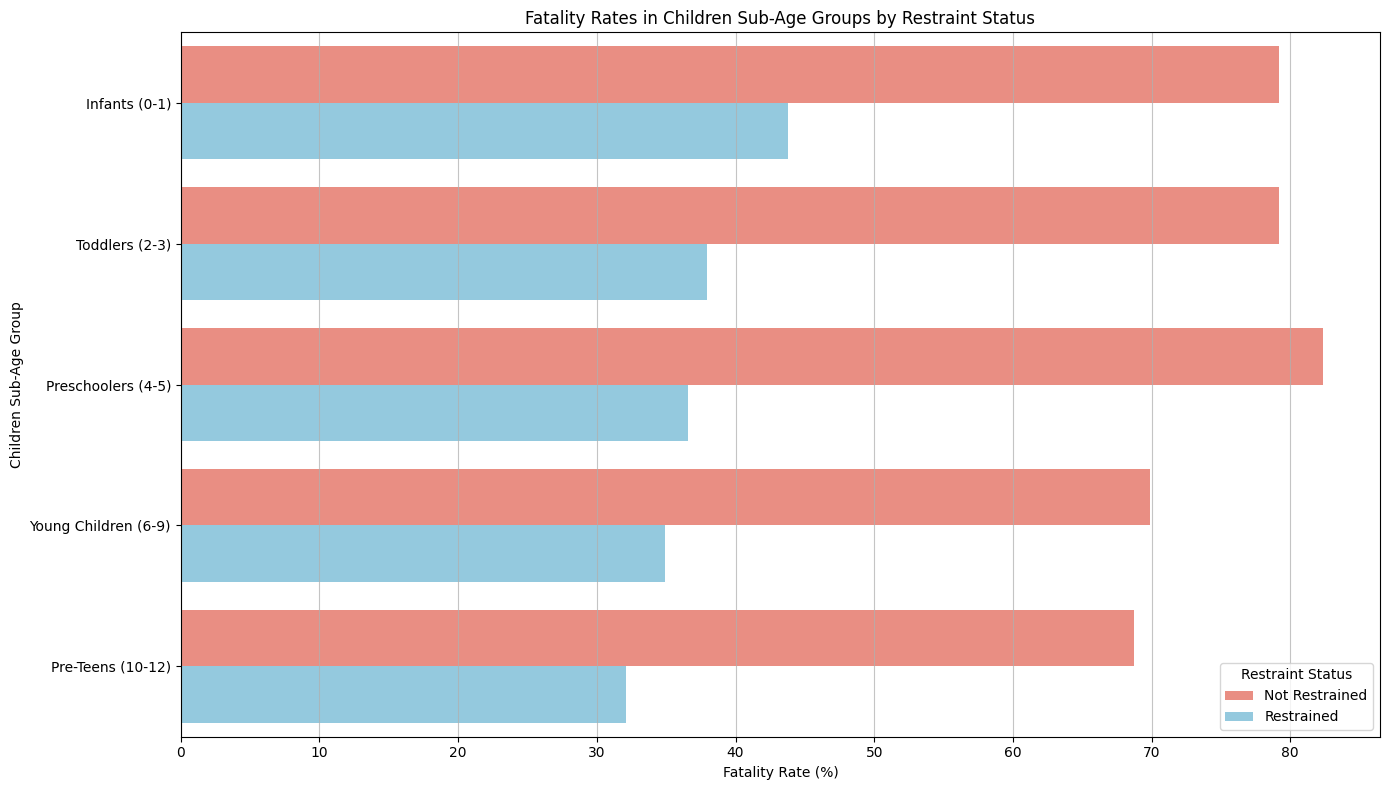

In [ ]:
# Filter for only 'Children (0-12)' from the main DataFrame
df_children_all = df_categorized_restraints_revised[
    df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)'
].copy()

# Define custom bins and labels for children subgroups (reusing definitions from earlier)
children_custom_bins = [0, 2, 4, 6, 10, 13] # Age ranges: [0,2), [2,4), [4,6), [6,10), [10,13)
children_custom_labels = [
    'Infants (0-1)',
    'Toddlers (2-3)',
    'Preschoolers (4-5)',
    'Young Children (6-9)',
    'Pre-Teens (10-12)'
]

# Create 'Children_Sub_Age_Group' column
df_children_all.loc[:, 'Children_Sub_Age_Group'] = pd.cut(
    df_children_all['AGE'],
    bins=children_custom_bins,
    labels=children_custom_labels,
    right=False,
    ordered=True
)

# Calculate total persons for each child sub-age group and restraint status
total_persons_children_subgroup = df_children_all.groupby(['Children_Sub_Age_Group', 'Restraint_Status_Final'], observed=True).size().reset_index(name='Total_Persons')

# Calculate total fatalities for each child sub-age group and restraint status
fatalities_children_subgroup = df_children_all[df_children_all['FATALITY_TYPE'] == 'FATAL'].groupby(['Children_Sub_Age_Group', 'Restraint_Status_Final'], observed=True).size().reset_index(name='Fatalities')

# Merge the two DataFrames
merged_children_data = pd.merge(total_persons_children_subgroup, fatalities_children_subgroup, on=['Children_Sub_Age_Group', 'Restraint_Status_Final'], how='left')

# Fill NaN values in 'Fatalities' with 0 (for combinations with no fatalities)
merged_children_data['Fatalities'] = merged_children_data['Fatalities'].fillna(0).astype(int)

# Calculate Fatality Rate
merged_children_data['Fatality Rate (%)'] = (merged_children_data['Fatalities'] / merged_children_data['Total_Persons'] * 100).round(2)

# --- Add Totals ---
# Create a copy and convert 'Children_Sub_Age_Group' to string type to allow adding non-categorical labels for totals
merged_children_data_for_display = merged_children_data.copy()
merged_children_data_for_display['Children_Sub_Age_Group'] = merged_children_data_for_display['Children_Sub_Age_Group'].astype(str)

# Calculate totals for 'Restrained' and 'Not Restrained' across all child sub-age groups
sub_group_totals = merged_children_data_for_display.groupby('Restraint_Status_Final').agg(
    Total_Persons=('Total_Persons', 'sum'),
    Fatalities=('Fatalities', 'sum')
).reset_index()

sub_group_totals['Fatality Rate (%)'] = (sub_group_totals['Fatalities'] / sub_group_totals['Total_Persons'] * 100).round(2)

# Create new rows for these totals with descriptive labels
restrained_total_row = sub_group_totals[sub_group_totals['Restraint_Status_Final'] == 'Restrained'].copy()
restrained_total_row['Children_Sub_Age_Group'] = 'Children (0-12) Total'
restrained_total_row.loc[:, 'Restraint_Status_Final'] = 'Restrained (Overall)' # More specific label

not_restrained_total_row = sub_group_totals[sub_group_totals['Restraint_Status_Final'] == 'Not Restrained'].copy()
not_restrained_total_row['Children_Sub_Age_Group'] = 'Children (0-12) Total'
not_restrained_total_row.loc[:, 'Restraint_Status_Final'] = 'Not Restrained (Overall)' # More specific label

# Calculate overall total for all children regardless of restraint status
overall_total_persons = merged_children_data_for_display['Total_Persons'].sum()
overall_fatalities = merged_children_data_for_display['Fatalities'].sum()
overall_fatality_rate = (overall_fatalities / overall_total_persons * 100).round(2)

overall_total_row = pd.DataFrame([
    {
        'Children_Sub_Age_Group': 'Grand Total (Children 0-12)',
        'Restraint_Status_Final': 'All (Overall)',
        'Total_Persons': overall_total_persons,
        'Fatalities': overall_fatalities,
        'Fatality Rate (%)': overall_fatality_rate
    }
])

# Append the total rows to merged_children_data_for_display
merged_children_data_for_display = pd.concat([
    merged_children_data_for_display,
    restrained_total_row,
    not_restrained_total_row,
    overall_total_row
], ignore_index=True)

print("Fatality Rates by Children Sub-Age Group and Restraint Status (with detailed breakdown and totals):")
display(merged_children_data_for_display)

# Plotting the fatality rates (using the original merged_children_data without totals for clarity)
plt.figure(figsize=(14, 8))
sns.barplot(x='Fatality Rate (%)', y='Children_Sub_Age_Group', hue='Restraint_Status_Final', data=merged_children_data, palette={'Restrained': 'skyblue', 'Not Restrained': 'salmon'})
plt.title('Fatality Rates in Children Sub-Age Groups by Restraint Status')
plt.xlabel('Fatality Rate (%)')
plt.ylabel('Children Sub-Age Group')
plt.grid(axis='x', alpha=0.75)
plt.legend(title='Restraint Status')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))
sns.lineplot(x='Children_Sub_Age_Group', y='Fatality Rate (%)', hue='Restraint_Status_Final', data=merged_children_data, marker='o', palette={'Restrained': 'blue', 'Not Restrained': 'red'})
plt.title('Trend of Fatality Rates Across Child Sub-Age Groups by Restraint Status')
plt.xlabel('Children Sub-Age Group')
plt.ylabel('Fatality Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Restraint Status')
plt.tight_layout()
plt.show()

### Heatmap of Child Fatality Rates by Sub-Age Group and Restraint Status

To provide a more granular visual representation of how child fatalities are distributed across different sub-age groups and restraint statuses, we will create a heatmap. This visualization will allow for easy identification of specific child age brackets and restraint conditions with the highest fatality rates.

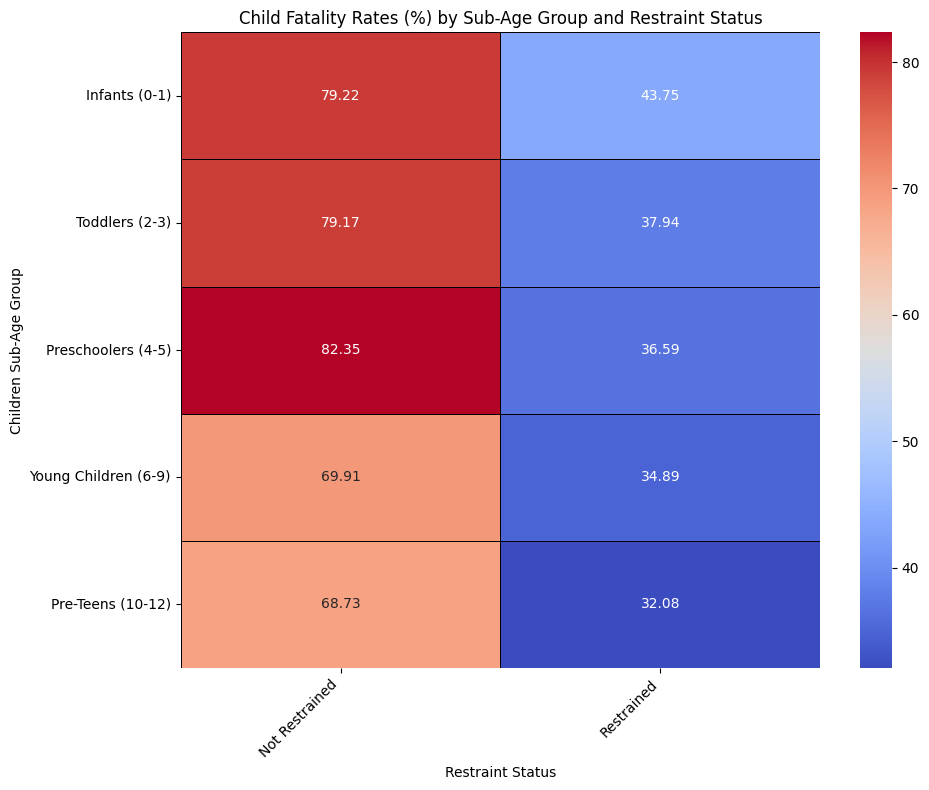

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for the heatmap
heatmap_children_data = merged_children_data.pivot_table(
    index='Children_Sub_Age_Group',
    columns='Restraint_Status_Final',
    values='Fatality Rate (%)',
    observed=True
)

# Ensure the columns for restraint status are in a logical order (e.g., 'Not Restrained', 'Restrained')
# This might already be handled by default, but explicitly setting it can be good practice
ordered_restraint_status = ['Not Restrained', 'Restrained']
heatmap_children_data = heatmap_children_data[ordered_restraint_status]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_children_data, cmap='coolwarm', annot=True, fmt='.2f', linewidths=.5, linecolor='black')
plt.title('Child Fatality Rates (%) by Sub-Age Group and Restraint Status')
plt.xlabel('Restraint Status')
plt.ylabel('Children Sub-Age Group')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Hour/Day/Month

### Fatalities by Hour of the Day

To understand when accidents are most likely to be fatal, we will analyze the distribution of fatalities across the hours of the day. This can help identify peak danger times.

Fatalities by Hour of the Day (excluding 'unknown' hours):


,HOUR_accident,Fatal_Count
0,0,1672
1,1,1573
2,2,1700
3,3,1119
4,4,958
5,5,1144
6,6,1292
7,7,1291
8,8,1176
9,9,1091


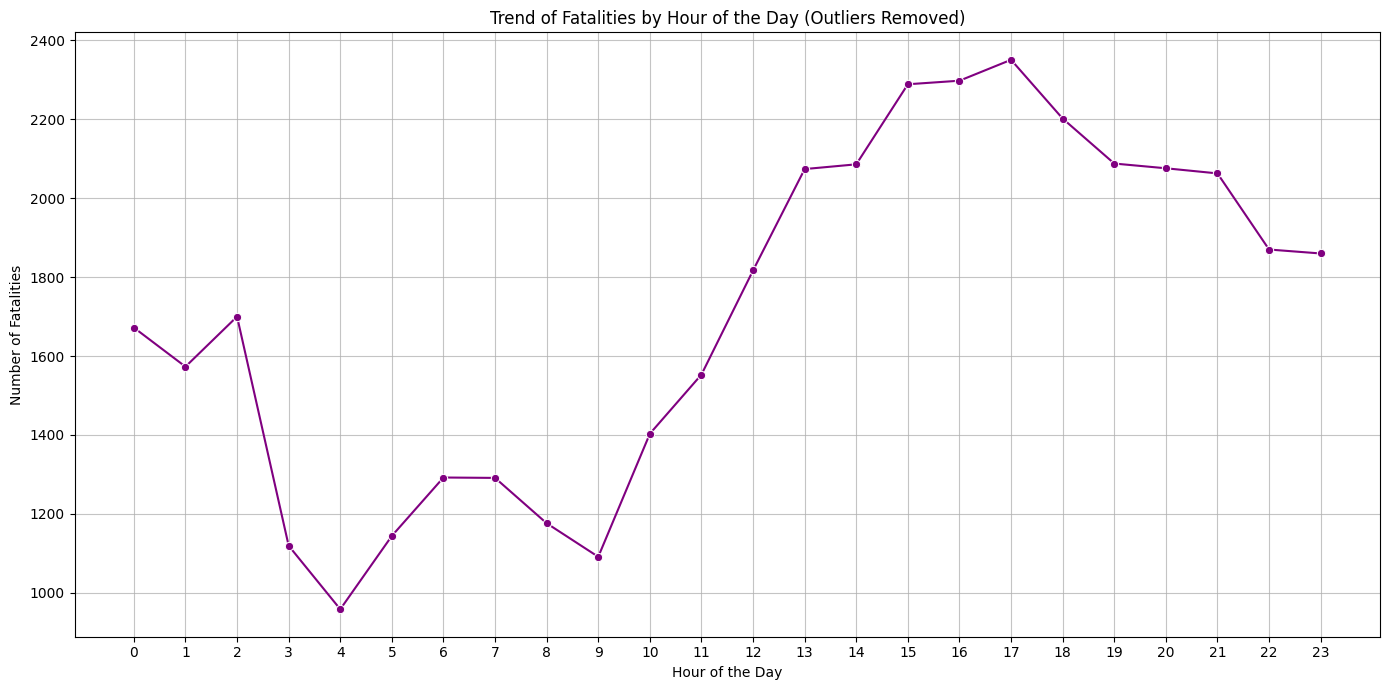

In [ ]:
# Convert 'HOUR_accident' to numeric, coercing errors to NaN
df_categorized_restraints_revised['HOUR_accident'] = pd.to_numeric(df_categorized_restraints_revised['HOUR_accident'], errors='coerce')

# Filter for fatal cases and drop rows where HOUR_accident is NaN
fatal_accidents_by_hour = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL') &
    (df_categorized_restraints_revised['HOUR_accident'].notna())
].copy()

# Group by hour and count fatalities
fatalities_by_hour = fatal_accidents_by_hour.groupby('HOUR_accident').size().reset_index(name='Fatal_Count')

# Filter out the '99' outlier from HOUR_accident, which represents unknown/not reported hours
fatalities_by_hour_cleaned = fatalities_by_hour[fatalities_by_hour['HOUR_accident'] != 99].copy()

# Sort by hour to ensure correct chronological order for plotting
fatalities_by_hour_cleaned = fatalities_by_hour_cleaned.sort_values('HOUR_accident')

print("Fatalities by Hour of the Day (excluding 'unknown' hours):")
display(fatalities_by_hour_cleaned)

# Plotting the trend of fatalities by hour
plt.figure(figsize=(14, 7))
sns.lineplot(x='HOUR_accident', y='Fatal_Count', data=fatalities_by_hour_cleaned, marker='o', color='purple')
plt.title('Trend of Fatalities by Hour of the Day (Outliers Removed)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fatalities')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(axis='both', alpha=0.75)
plt.tight_layout()
plt.show()

### Fatalities in Children (0-12) by Hour of the Day

To focus on child safety, let's analyze the distribution of fatalities specifically within the 'Children (0-12)' age group across the hours of the day. This will highlight peak danger times for children.

Fatalities in Children (0-12) by Hour of the Day (excluding 'unknown' hours):


,HOUR_accident,Fatal_Count_Children
0,0,38
1,1,34
2,2,33
3,3,30
4,4,23
5,5,39
6,6,38
7,7,78
8,8,74
9,9,53



Total Fatalities for Children (0-12): 1942

Total Fatalities for Children (0-12) between 1 PM and 7 PM: 948
Percentage of child fatalities between 1 PM and 7 PM: 48.82%


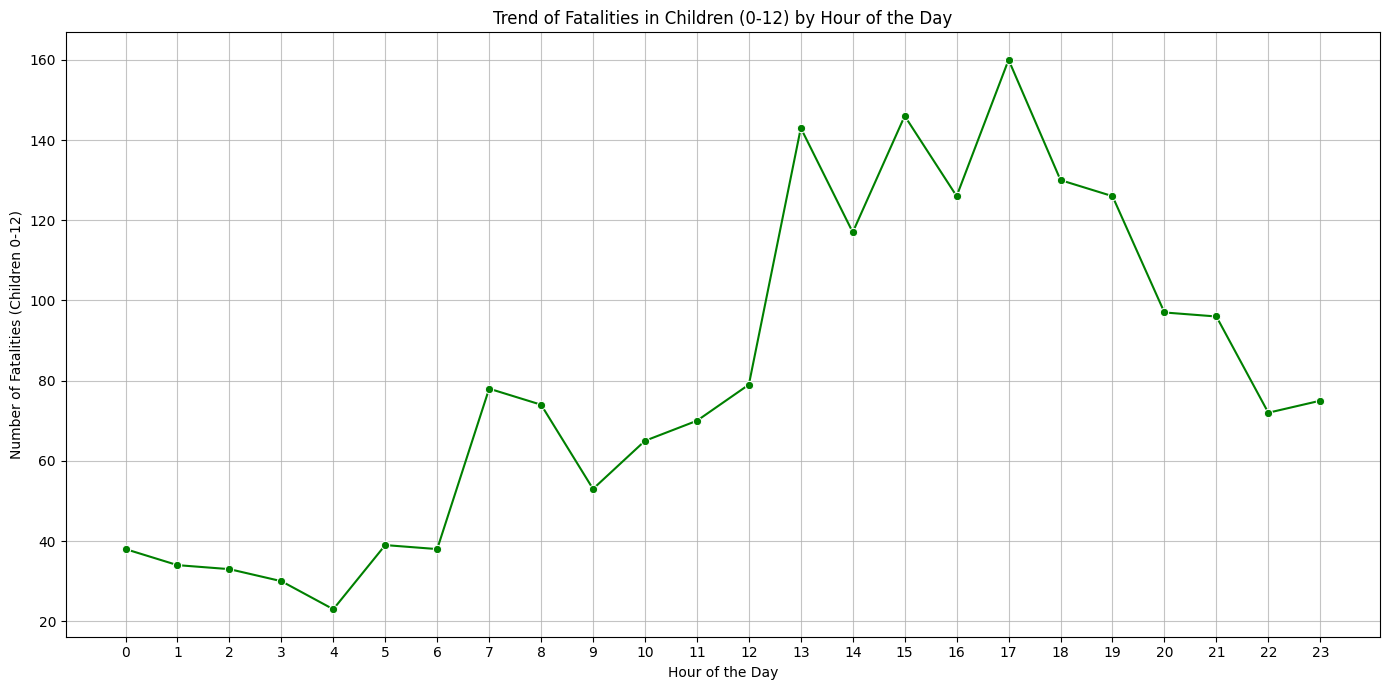

In [ ]:
# Filter for fatal cases within the 'Children (0-12)' age group
fatal_children_by_hour = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL') &
    (df_categorized_restraints_revised['HOUR_accident'].notna()) &
    (df_categorized_restraints_revised['HOUR_accident'] != 99)
].copy()

# Group by hour and count fatalities
fatalities_children_by_hour = fatal_children_by_hour.groupby('HOUR_accident').size().reset_index(name='Fatal_Count_Children')

# Sort by hour to ensure correct chronological order for plotting
fatalities_children_by_hour = fatalities_children_by_hour.sort_values('HOUR_accident')

print("Fatalities in Children (0-12) by Hour of the Day (excluding 'unknown' hours):")
display(fatalities_children_by_hour)

# Add the sum of fatalities
total_children_fatalities_by_hour = fatalities_children_by_hour['Fatal_Count_Children'].sum()
print(f"\nTotal Fatalities for Children (0-12): {total_children_fatalities_by_hour}")

# Calculate and print fatalities from 1 PM to 7 PM
# 1 PM is hour 13, 7 PM is hour 19
fatalities_1pm_to_7pm = fatalities_children_by_hour[
    (fatalities_children_by_hour['HOUR_accident'] >= 13) &
    (fatalities_children_by_hour['HOUR_accident'] <= 19)
]['Fatal_Count_Children'].sum()
print(f"\nTotal Fatalities for Children (0-12) between 1 PM and 7 PM: {fatalities_1pm_to_7pm}")

# Calculate the percentage of child fatalities that occur between 1 PM and 7 PM
percentage_1pm_to_7pm = (fatalities_1pm_to_7pm / total_children_fatalities_by_hour) * 100
print(f"Percentage of child fatalities between 1 PM and 7 PM: {percentage_1pm_to_7pm:.2f}%")

# Plotting the trend of fatalities for children by hour
plt.figure(figsize=(14, 7))
sns.lineplot(x='HOUR_accident', y='Fatal_Count_Children', data=fatalities_children_by_hour, marker='o', color='green')
plt.title('Trend of Fatalities in Children (0-12) by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fatalities (Children 0-12)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(axis='both', alpha=0.75)
plt.tight_layout()
plt.show()

### Impact of Restraint Usage on Child Fatalities During Peak Hours (1 PM - 7 PM)

In [ ]:
# Filter for 'Children (0-12)', fatal cases, and peak hours (1 PM to 7 PM, i.e., 13 to 19)
peak_hour_children_fatalities = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL') &
    (df_categorized_restraints_revised['HOUR_accident'] >= 13) &
    (df_categorized_restraints_revised['HOUR_accident'] <= 19) &
    (df_categorized_restraints_revised['HOUR_accident'].notna()) &
    (df_categorized_restraints_revised['HOUR_accident'] != 99)
].copy()

# Calculate total persons (fatal and non-fatal) for 'Children (0-12)' within peak hours by restraint status
peak_hour_children_total = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['HOUR_accident'] >= 13) &
    (df_categorized_restraints_revised['HOUR_accident'] <= 19) &
    (df_categorized_restraints_revised['HOUR_accident'].notna()) &
    (df_categorized_restraints_revised['HOUR_accident'] != 99)
].groupby('Restraint_Status_Final').size().reset_index(name='Total_Persons_Peak_Hours')

# Group by Restraint_Status_Final and count fatalities during peak hours
peak_hour_fatalities_by_restraint = peak_hour_children_fatalities.groupby('Restraint_Status_Final').size().reset_index(name='Fatal_Count_Peak_Hours')

# Merge total persons and fatal counts
peak_hour_impact_df = pd.merge(
    peak_hour_children_total,
    peak_hour_fatalities_by_restraint,
    on='Restraint_Status_Final',
    how='left'
)

# Fill NaN fatalities with 0
peak_hour_impact_df['Fatal_Count_Peak_Hours'] = peak_hour_impact_df['Fatal_Count_Peak_Hours'].fillna(0).astype(int)

# Calculate Fatality Rate for peak hours
peak_hour_impact_df['Fatality_Rate_Peak_Hours (%)'] = (peak_hour_impact_df['Fatal_Count_Peak_Hours'] / peak_hour_impact_df['Total_Persons_Peak_Hours'] * 100).round(2)

print("Impact of Restraint Usage on Child Fatalities During Peak Hours (1 PM - 7 PM):")
display(peak_hour_impact_df)


Impact of Restraint Usage on Child Fatalities During Peak Hours (1 PM - 7 PM):


,Restraint_Status_Final,Total_Persons_Peak_Hours,Fatal_Count_Peak_Hours,Fatality_Rate_Peak_Hours (%)
0,Not Restrained,545,395,72.48
1,Restrained,1638,553,33.76


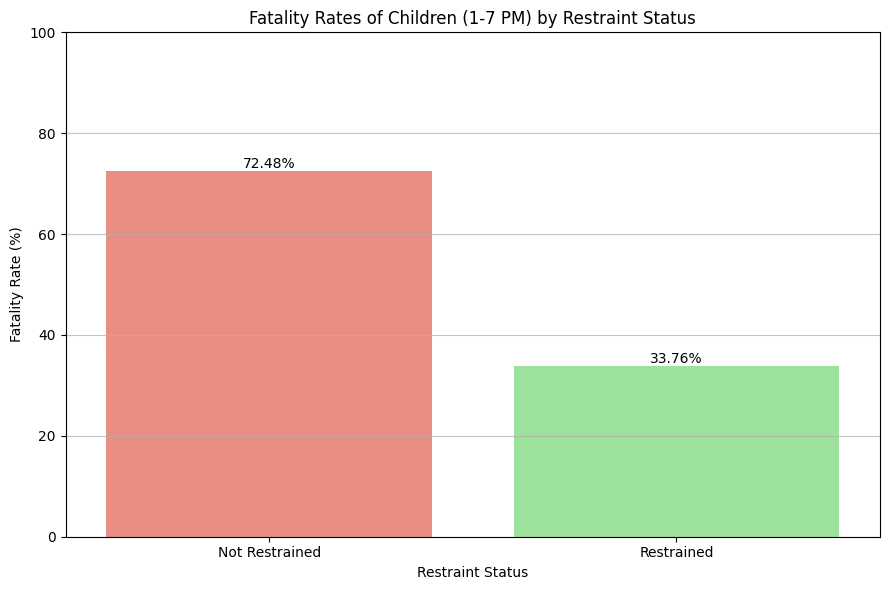

In [ ]:
# Plotting the fatality rates during peak hours by restraint status
plt.figure(figsize=(9, 6))
sns.barplot(
    x='Restraint_Status_Final',
    y='Fatality_Rate_Peak_Hours (%)',
    data=peak_hour_impact_df,
    palette={'Restrained': 'lightgreen', 'Not Restrained': 'salmon'},
    hue='Restraint_Status_Final',
    legend=False
)
plt.title('Fatality Rates of Children (1-7 PM) by Restraint Status')
plt.xlabel('Restraint Status')
plt.ylabel('Fatality Rate (%)')
plt.ylim(0, 100) # Ensure y-axis covers full percentage range
plt.grid(axis='y', alpha=0.75)

# Add percentage labels to the bars
for index, row in peak_hour_impact_df.iterrows():
    plt.text(row.name, row['Fatality_Rate_Peak_Hours (%)'], f'{row['Fatality_Rate_Peak_Hours (%)']:.2f}%',
             color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Fatalities by Day of the Week

To understand if certain days of the week are more prone to fatal accidents, we will analyze the distribution of fatalities across the days. We will also include the day names for better readability.

Fatalities by Day of the Week:


,DAY_WEEK,Fatal_Count,DAY_NAME
0,1,6880,Sunday
1,2,5271,Monday
2,3,4770,Tuesday
3,4,4994,Wednesday
4,5,5369,Thursday
5,6,6353,Friday
6,7,7640,Saturday


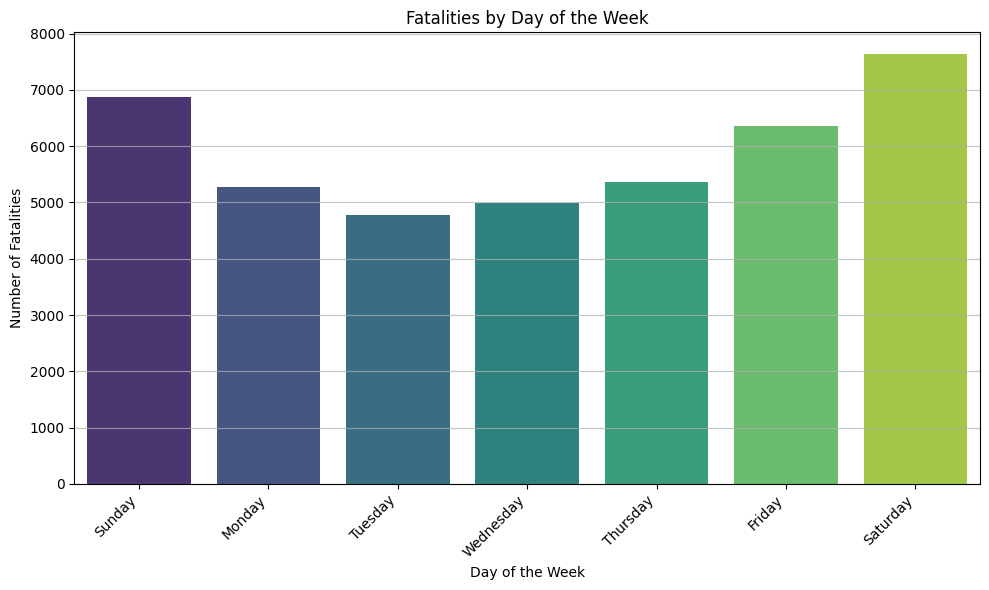

In [ ]:
# Convert 'DAY_WEEK' to numeric, coercing errors to NaN
df_categorized_restraints_revised['DAY_WEEK'] = pd.to_numeric(df_categorized_restraints_revised['DAY_WEEK'], errors='coerce')

# Filter for fatal cases and drop rows where DAY_WEEK is NaN
fatal_accidents_by_day = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL') &
    (df_categorized_restraints_revised['DAY_WEEK'].notna())
].copy()

# Group by day of the week and count fatalities
fatalities_by_day_week = fatal_accidents_by_day.groupby('DAY_WEEK').size().reset_index(name='Fatal_Count')

# Map day numbers to names for better readability
day_names_map = {
    1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
    5: 'Thursday', 6: 'Friday', 7: 'Saturday'
}
fatalities_by_day_week['DAY_NAME'] = fatalities_by_day_week['DAY_WEEK'].map(day_names_map)

# Sort by day of the week to ensure correct chronological order for plotting
fatalities_by_day_week = fatalities_by_day_week.sort_values('DAY_WEEK')

print("Fatalities by Day of the Week:")
display(fatalities_by_day_week)

# Plotting the trend of fatalities by day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x='DAY_NAME', y='Fatal_Count', data=fatalities_by_day_week, palette='viridis', hue='DAY_NAME', legend=False)
plt.title('Fatalities by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Fatalities')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Fatalities in Children (0-12) by Day of the Week

To understand if certain days of the week are more prone to fatal accidents for children, we will analyze the distribution of fatalities across the days specifically for the 'Children (0-12)' age group.

Fatalities in Children (0-12) by Day of the Week:


,DAY_WEEK,Fatal_Count_Children,DAY_NAME
0,1,349,Sunday
1,2,275,Monday
2,3,170,Tuesday
3,4,201,Wednesday
4,5,254,Thursday
5,6,325,Friday
6,7,370,Saturday


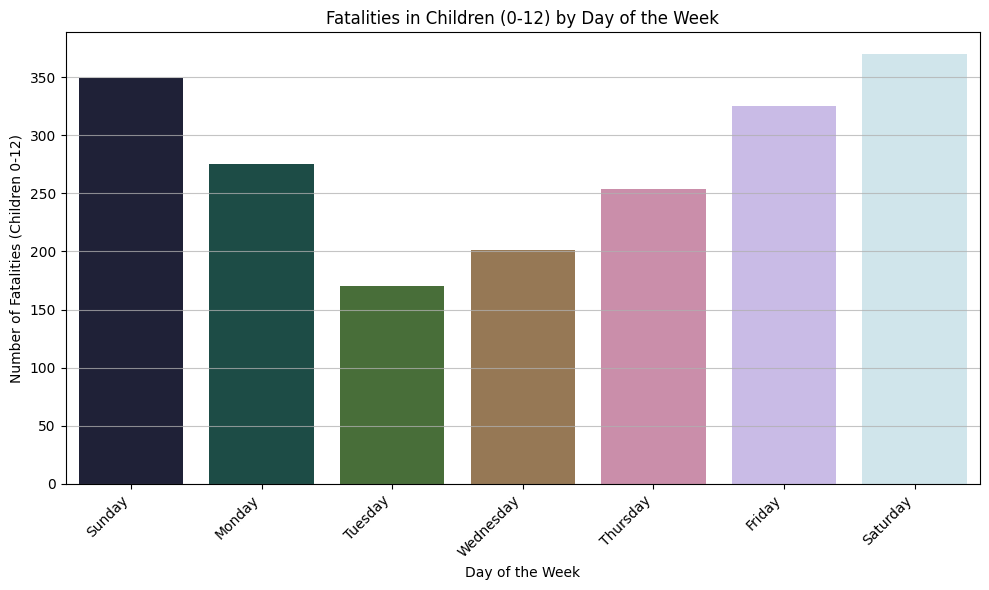

In [ ]:
# Filter for 'Children (0-12)', fatal cases, and drop rows where DAY_WEEK is NaN
fatal_children_by_day = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL') &
    (df_categorized_restraints_revised['DAY_WEEK'].notna())
].copy()

# Group by day of the week and count fatalities
fatalities_children_by_day_week = fatal_children_by_day.groupby('DAY_WEEK').size().reset_index(name='Fatal_Count_Children')

# Map day numbers to names for better readability
day_names_map = {
    1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
    5: 'Thursday', 6: 'Friday', 7: 'Saturday'
}
fatalities_children_by_day_week['DAY_NAME'] = fatalities_children_by_day_week['DAY_WEEK'].map(day_names_map)

# Sort by day of the week to ensure correct chronological order for plotting
fatalities_children_by_day_week = fatalities_children_by_day_week.sort_values('DAY_WEEK')

print("Fatalities in Children (0-12) by Day of the Week:")
display(fatalities_children_by_day_week)

# Plotting the trend of fatalities for children by day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x='DAY_NAME', y='Fatal_Count_Children', data=fatalities_children_by_day_week, palette='cubehelix', hue='DAY_NAME', legend=False)
plt.title('Fatalities in Children (0-12) by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Fatalities (Children 0-12)')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Child Fatalities (0-12) by Hour and Day of the Week

To get a more granular understanding, let's combine the analysis of child fatalities by hour and day of the week. This heatmap will highlight the specific hours on each day where child fatalities are most frequent.

Child Fatalities Matrix (Day of Week vs. Hour of Day):


HOUR_accident,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DAY_WEEK,,,,,,,,,,,,,,,,,,,,,
Monday,3,4,6,3,1,5,13,14,13,13,...,17,9,32,23,15,24,8,8,7,4
Tuesday,1,2,1,0,1,6,8,8,6,5,...,17,14,12,15,10,8,8,9,8,3
Wednesday,5,4,0,8,3,2,2,17,6,7,...,7,21,7,18,12,11,8,15,5,11
Thursday,2,0,5,0,2,13,4,14,24,7,...,15,23,12,29,17,13,7,11,11,13
Friday,6,8,1,2,2,1,5,18,13,10,...,14,17,16,22,32,26,12,13,13,11
Saturday,13,9,3,5,2,5,3,1,7,7,...,23,30,22,32,24,31,36,26,19,14
Sunday,8,7,17,12,12,7,3,6,5,4,...,24,32,25,21,20,13,18,14,9,19


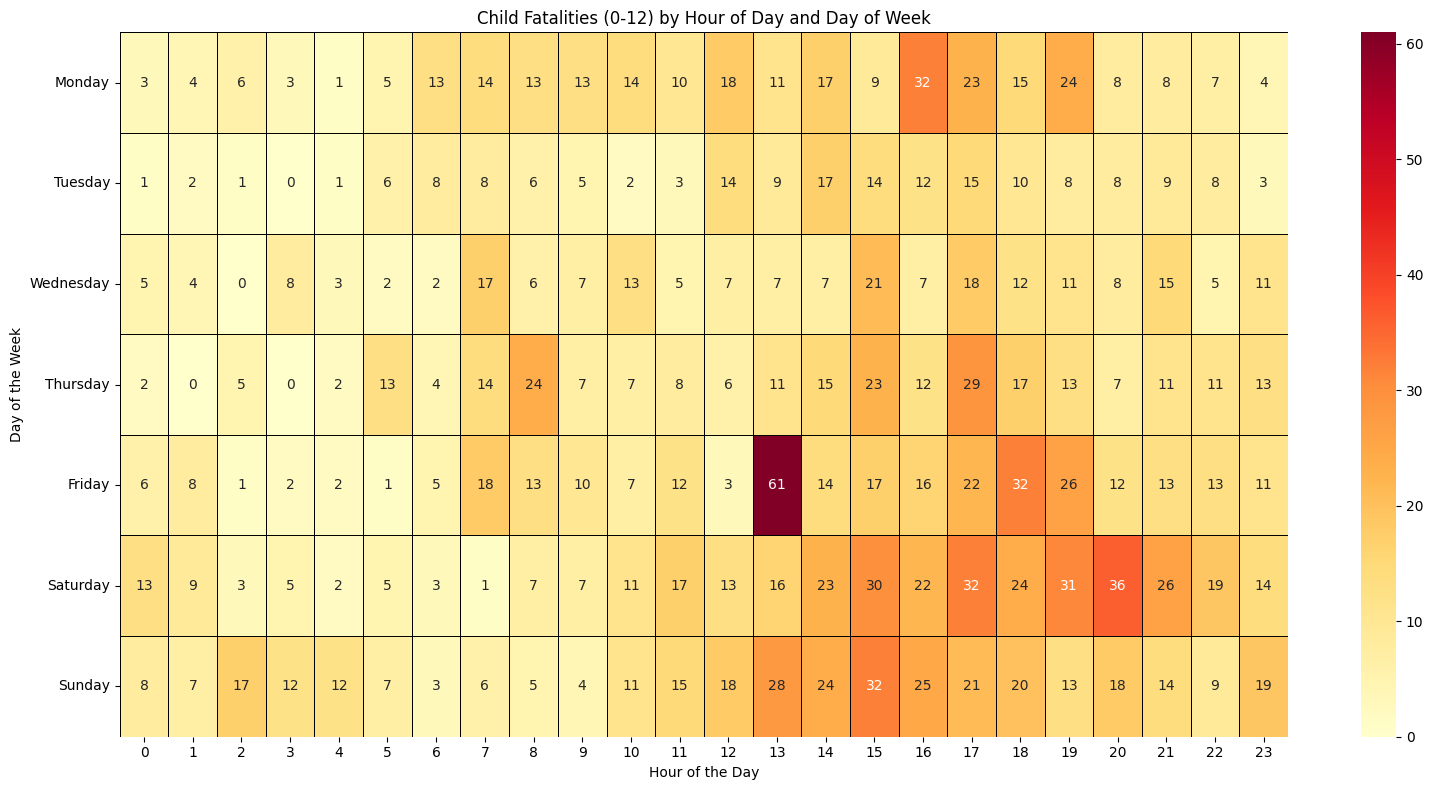

In [ ]:
# Ensure 'DAY_WEEK' and 'HOUR_accident' are numeric and clean (no NaNs or outliers)
df_categorized_restraints_revised['DAY_WEEK'] = pd.to_numeric(df_categorized_restraints_revised['DAY_WEEK'], errors='coerce')
df_categorized_restraints_revised['HOUR_accident'] = pd.to_numeric(df_categorized_restraints_revised['HOUR_accident'], errors='coerce')

# Filter for 'Children (0-12)', fatal cases, and valid DAY_WEEK/HOUR_accident
children_fatalities_by_day_hour = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL') &
    (df_categorized_restraints_revised['DAY_WEEK'].notna()) &
    (df_categorized_restraints_revised['HOUR_accident'].notna()) &
    (df_categorized_restraints_revised['HOUR_accident'] != 99) # Remove 'unknown' hour
].copy()

# Group by DAY_WEEK and HOUR_accident, then count fatalities
fatalities_matrix = children_fatalities_by_day_hour.groupby(['DAY_WEEK', 'HOUR_accident']).size().unstack(fill_value=0)

# Map day numbers to names for better readability on the heatmap
day_names_map = {
    1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
    5: 'Thursday', 6: 'Friday', 7: 'Saturday'
}
fatalities_matrix = fatalities_matrix.rename(index=day_names_map)

# Reorder the rows to start from Monday to Sunday for a standard week view
ordered_day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fatalities_matrix = fatalities_matrix.reindex(ordered_day_names)

print("Child Fatalities Matrix (Day of Week vs. Hour of Day):")
display(fatalities_matrix)

# Plotting the heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(fatalities_matrix, cmap='YlOrRd', annot=True, fmt='d', linewidths=.5, linecolor='black')
plt.title('Child Fatalities (0-12) by Hour of Day and Day of Week')
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Fatalities by State and Children Sub-Age Group

To understand geographical variations in child fatalities and how different sub-age groups are affected across states, we will analyze and visualize the number of fatalities by state and children's sub-age groups.

In [ ]:
# Filter for fatal cases within the 'Children (0-12)' age group from the categorized restraint data
df_children_fatal_by_state = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL')
].copy()

# Define custom bins and labels for children subgroups (reusing definitions from earlier)
children_custom_bins = [0, 2, 4, 6, 10, 13] # Age ranges: [0,2), [2,4), [4,6), [6,10), [10,13)
children_custom_labels = [
    'Infants (0-1)',
    'Toddlers (2-3)',
    'Preschoolers (4-5)',
    'Young Children (6-9)',
    'Pre-Teens (10-12)'
]

# Create a new column 'Children_Sub_Age_Group' within the filtered DataFrame
df_children_fatal_by_state.loc[:, 'Children_Sub_Age_Group'] = pd.cut(
    df_children_fatal_by_state['AGE'],
    bins=children_custom_bins,
    labels=children_custom_labels,
    right=False,
    ordered=True
)

# Group by State and Children_Sub_Age_Group to count fatalities
fatalities_by_state_children_subgroup = df_children_fatal_by_state.groupby(['STATENAME_accident', 'Children_Sub_Age_Group'], observed=True).size().unstack(fill_value=0)

# Calculate total fatalities per state for children
fatalities_by_state_children_subgroup['Total_Fatalities_Children'] = fatalities_by_state_children_subgroup.sum(axis=1)

# Sort by total fatalities for better visualization
fatalities_by_state_children_subgroup = fatalities_by_state_children_subgroup.sort_values(by='Total_Fatalities_Children', ascending=False)

print("Fatalities by State and Children Sub-Age Group:")
display(fatalities_by_state_children_subgroup)

Fatalities by State and Children Sub-Age Group:


Children_Sub_Age_Group,Infants (0-1),Toddlers (2-3),Preschoolers (4-5),Young Children (6-9),Pre-Teens (10-12),Total_Fatalities_Children
STATENAME_accident,,,,,,
Texas,42,38,81,78,55,294
California,22,25,21,37,41,146
Florida,26,21,23,39,16,125
North Carolina,11,12,13,28,23,87
Arizona,9,9,16,24,19,77
Georgia,9,8,12,23,14,66
Illinois,12,12,12,13,15,64
Tennessee,11,16,10,14,12,63
Missouri,12,12,11,16,11,62


<Figure size 1600x1000 with 0 Axes>

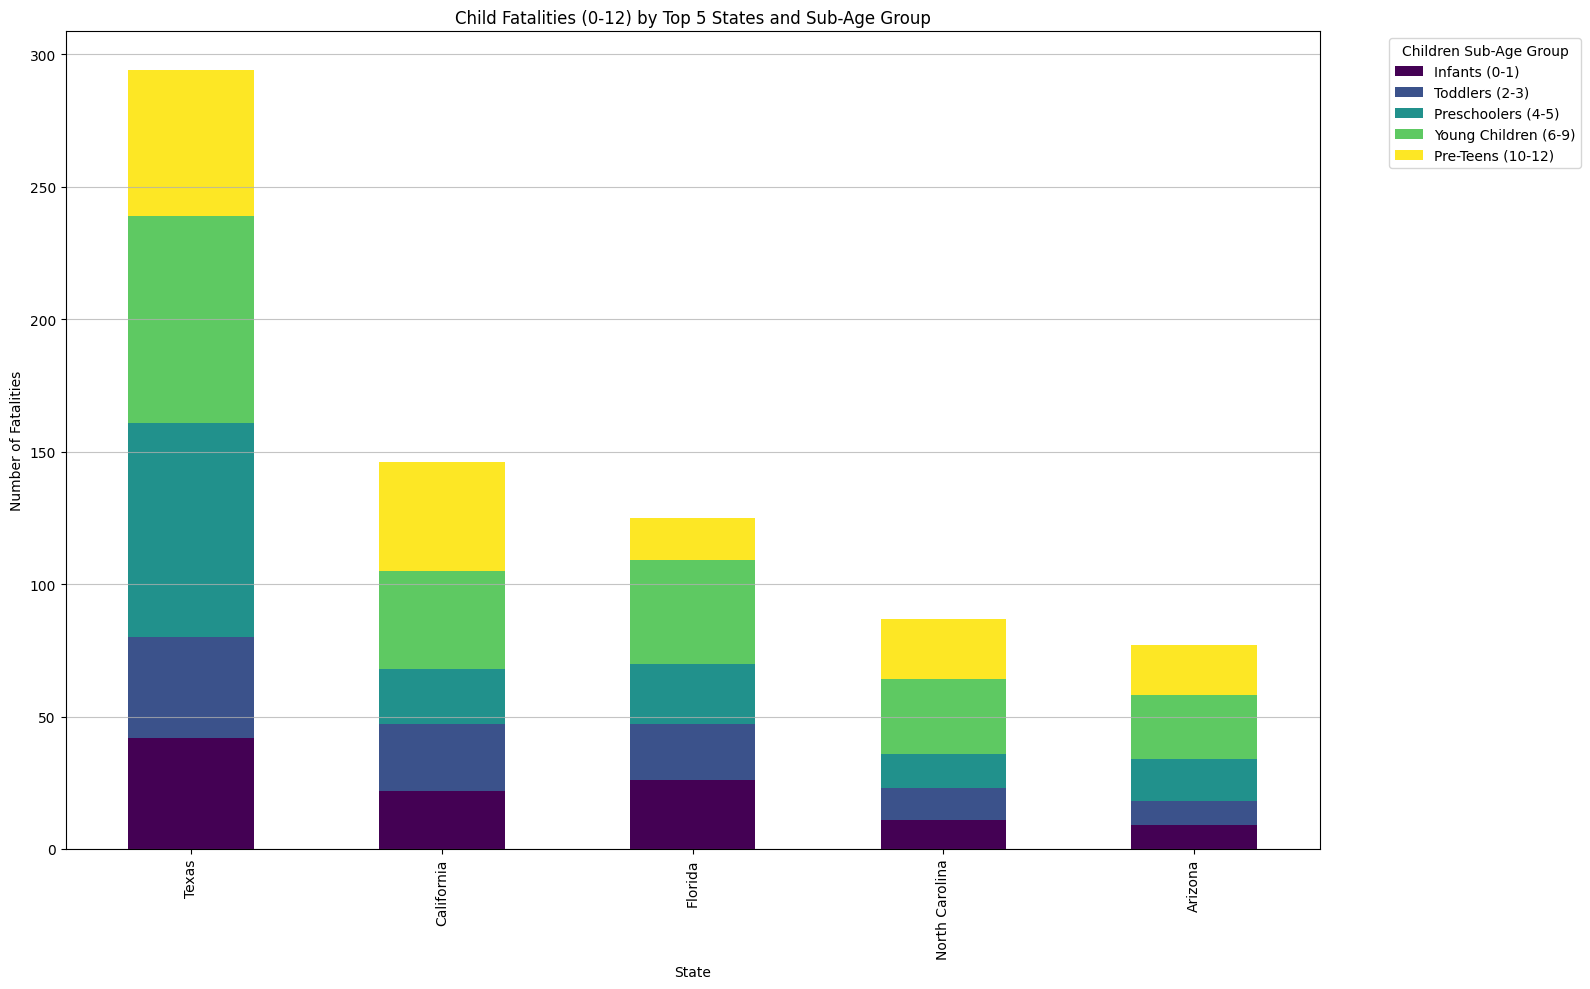

In [ ]:
# Prepare data for stacked bar plot (excluding 'Total_Fatalities_Children' for plotting the stacked bars)
# Filter for top 5 states
top_5_states = fatalities_by_state_children_subgroup.head(5).index
plot_data_top_5 = fatalities_by_state_children_subgroup.loc[top_5_states].drop(columns='Total_Fatalities_Children')

plt.figure(figsize=(16, 10))
plot_data_top_5.plot(kind='bar', stacked=True, colormap='viridis', figsize=(16, 10))
plt.title('Child Fatalities (0-12) by Top 5 States and Sub-Age Group')
plt.xlabel('State')
plt.ylabel('Number of Fatalities')
plt.xticks(rotation=90)
plt.legend(title='Children Sub-Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Heatmap of Child Fatalities by State and Sub-Age Group

To provide a more granular visual representation of how child fatalities are distributed across states and within specific sub-age groups, we will create a heatmap. This visualization will allow for easy identification of states and age brackets with the highest number of fatalities.

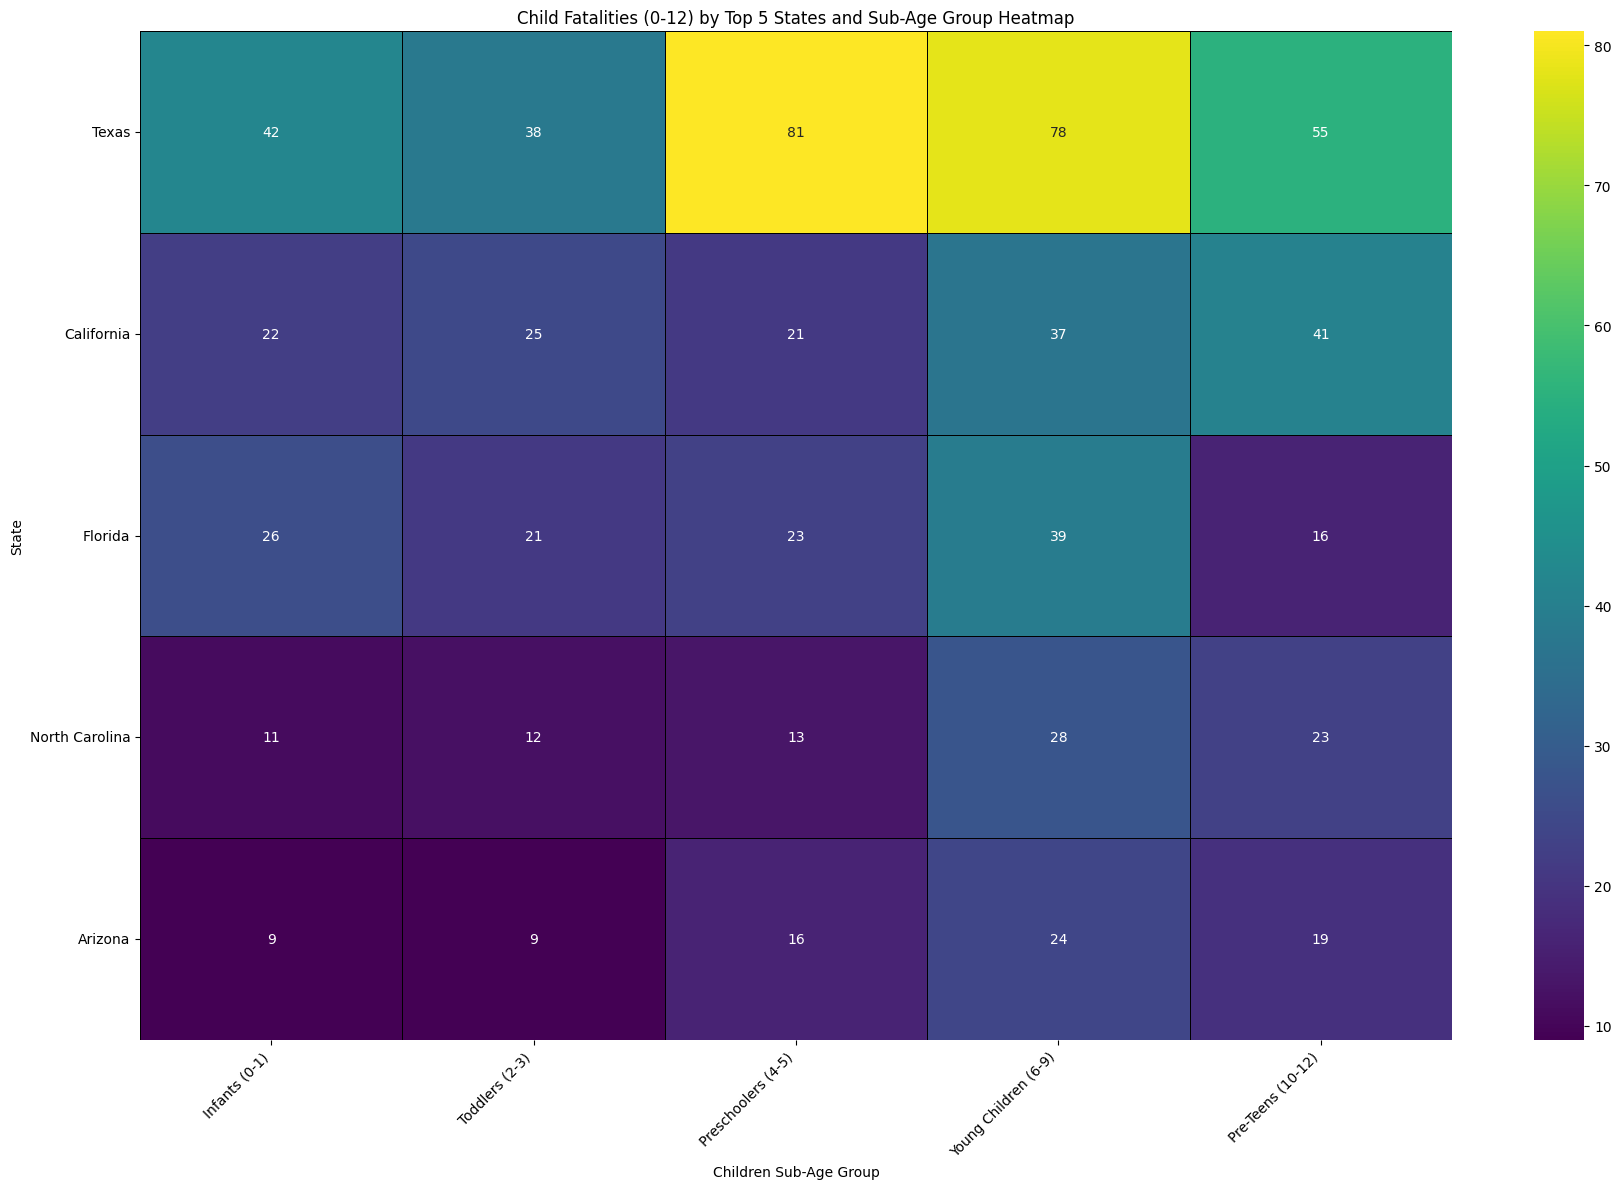

In [ ]:
plot_data = fatalities_by_state_children_subgroup.head(5).drop(columns='Total_Fatalities_Children')

plt.figure(figsize=(18, 12))
sns.heatmap(plot_data, cmap='viridis', annot=True, fmt='d', linewidths=.5, linecolor='black')
plt.title('Child Fatalities (0-12) by Top 5 States and Sub-Age Group Heatmap')
plt.xlabel('Children Sub-Age Group')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Child Fatality Rates (0-11) per 100,000 Population by Top 5 States

To normalize the child fatality counts across states with varying populations, we will calculate the fatality rate per 100,000 children (aged 0-11) for the top 5 states identified. This will provide a more accurate comparison of the safety risks for children in these states.

Child Fatality Rates (0-11) per 100,000 Population by Top 5 States:


,STATENAME_accident,Total_Fatalities,Child_Population_0_11,Fatality_Rate_Per_100k_Children
0,Texas,294,4973634,5.91
1,California,146,5373216,2.72
2,Florida,125,2909526,4.30
3,North Carolina,87,1526526,5.70
4,Arizona,77,1013435,7.60


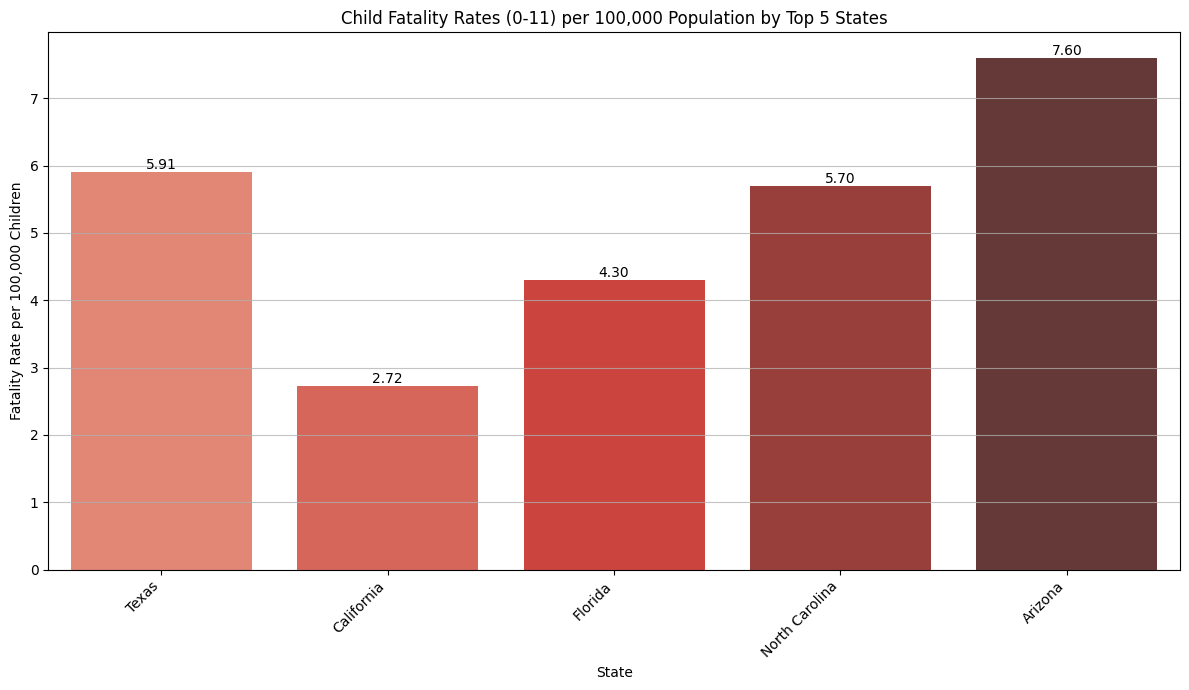

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Children age 0-11 populations for the top 5 states
child_population_data = {
    'STATENAME_accident': ['Texas', 'California', 'Florida', 'North Carolina', 'Arizona'],
    'Child_Population_0_11': [4973634, 5373216, 2909526, 1526526, 1013435]
}
child_population_df = pd.DataFrame(child_population_data)

# Get total child fatalities (0-12) for the top 5 states from the previously generated fatalities_by_state_children_subgroup
top_5_states_fatalities = fatalities_by_state_children_subgroup.head(5)[['Total_Fatalities_Children']].reset_index()
top_5_states_fatalities.rename(columns={'Total_Fatalities_Children': 'Total_Fatalities'}, inplace=True)

# Merge population data with fatality data
merged_fatality_population = pd.merge(top_5_states_fatalities, child_population_df, on='STATENAME_accident', how='inner')

# Calculate Fatality Rate per 100,000 children
merged_fatality_population['Fatality_Rate_Per_100k_Children'] = (merged_fatality_population['Total_Fatalities'] / merged_fatality_population['Child_Population_0_11'] * 100000).round(2)

print("Child Fatality Rates (0-11) per 100,000 Population by Top 5 States:")
display(merged_fatality_population)

# Plotting the Fatality Rates
plt.figure(figsize=(12, 7))
sns.barplot(x='STATENAME_accident', y='Fatality_Rate_Per_100k_Children', data=merged_fatality_population, palette='Reds_d', hue='STATENAME_accident', legend=False)
plt.title('Child Fatality Rates (0-11) per 100,000 Population by Top 5 States')
plt.xlabel('State')
plt.ylabel('Fatality Rate per 100,000 Children')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for index, row in merged_fatality_population.iterrows():
    plt.text(index, row['Fatality_Rate_Per_100k_Children'], f'{row['Fatality_Rate_Per_100k_Children']:.2f}', color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# Filter df_children_all for the top 5 states
top_5_states_names = ['Texas', 'California', 'Florida', 'North Carolina', 'Arizona']
df_children_all_top_5 = df_children_all[df_children_all['STATENAME_accident'].isin(top_5_states_names)].copy()

# Calculate total persons for each state and child sub-age group
total_persons_subgroup_top_5 = df_children_all_top_5.groupby(['STATENAME_accident', 'Children_Sub_Age_Group'], observed=True).size().reset_index(name='Total_Persons')

# Calculate total fatalities for each state and child sub-age group
fatalities_subgroup_top_5 = df_children_all_top_5[df_children_all_top_5['FATALITY_TYPE'] == 'FATAL'].groupby(['STATENAME_accident', 'Children_Sub_Age_Group'], observed=True).size().reset_index(name='Fatalities')

# Merge the two DataFrames
merged_children_subgroup_top_5 = pd.merge(
    total_persons_subgroup_top_5,
    fatalities_subgroup_top_5,
    on=['STATENAME_accident', 'Children_Sub_Age_Group'],
    how='left'
)

# Fill NaN values in 'Fatalities' with 0
merged_children_subgroup_top_5['Fatalities'] = merged_children_subgroup_top_5['Fatalities'].fillna(0).astype(int)

# Calculate Fatality Rate
merged_children_subgroup_top_5['Fatality Rate (%)'] = (
    merged_children_subgroup_top_5['Fatalities'] / merged_children_subgroup_top_5['Total_Persons'] * 100
).round(2)

print("Fatality Rates by Children Sub-Age Group in Top 5 States:")
display(merged_children_subgroup_top_5)

Fatality Rates by Children Sub-Age Group in Top 5 States:


,STATENAME_accident,Children_Sub_Age_Group,Total_Persons,Fatalities,Fatality Rate (%)
0,Arizona,Infants (0-1),18,9,50.00
1,Arizona,Toddlers (2-3),14,9,64.29
2,Arizona,Preschoolers (4-5),26,16,61.54
3,Arizona,Young Children (6-9),48,24,50.00
4,Arizona,Pre-Teens (10-12),31,19,61.29
5,California,Infants (0-1),59,22,37.29
6,California,Toddlers (2-3),55,25,45.45
7,California,Preschoolers (4-5),54,21,38.89
8,California,Young Children (6-9),119,37,31.09
9,California,Pre-Teens (10-12),105,41,39.05


In [ ]:
# Plotting the fatality rates by children sub-age group and state
plt.figure(figsize=(16, 9))
sns.barplot(
    x='STATENAME_accident',
    y='Fatality Rate (%)',
    hue='Children_Sub_Age_Group',
    data=merged_children_subgroup_top_5,
    palette='tab10'
)
plt.title('Child Fatality Rates by Sub-Age Group and State (Top 5 States)')
plt.xlabel('State')
plt.ylabel('Fatality Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Children Sub-Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of `SEAT_POSNAME` (Seat Position)

Summary of Seat Position Categories:


,Count,Percentage
SEAT_POSNAME,,
"Front Seat, Left Side",54013,70.33
"Front Seat, Right Side",12019,15.65
"Second Seat, Right Side",3698,4.82
"Second Seat, Left Side",3500,4.56
"Second Seat, Middle",1004,1.31
Reported as Unknown,587,0.76
Other Passenger in enclosed passenger or cargo area,585,0.76
"Third Seat, Left Side",217,0.28
"Third Seat, Right Side",212,0.28


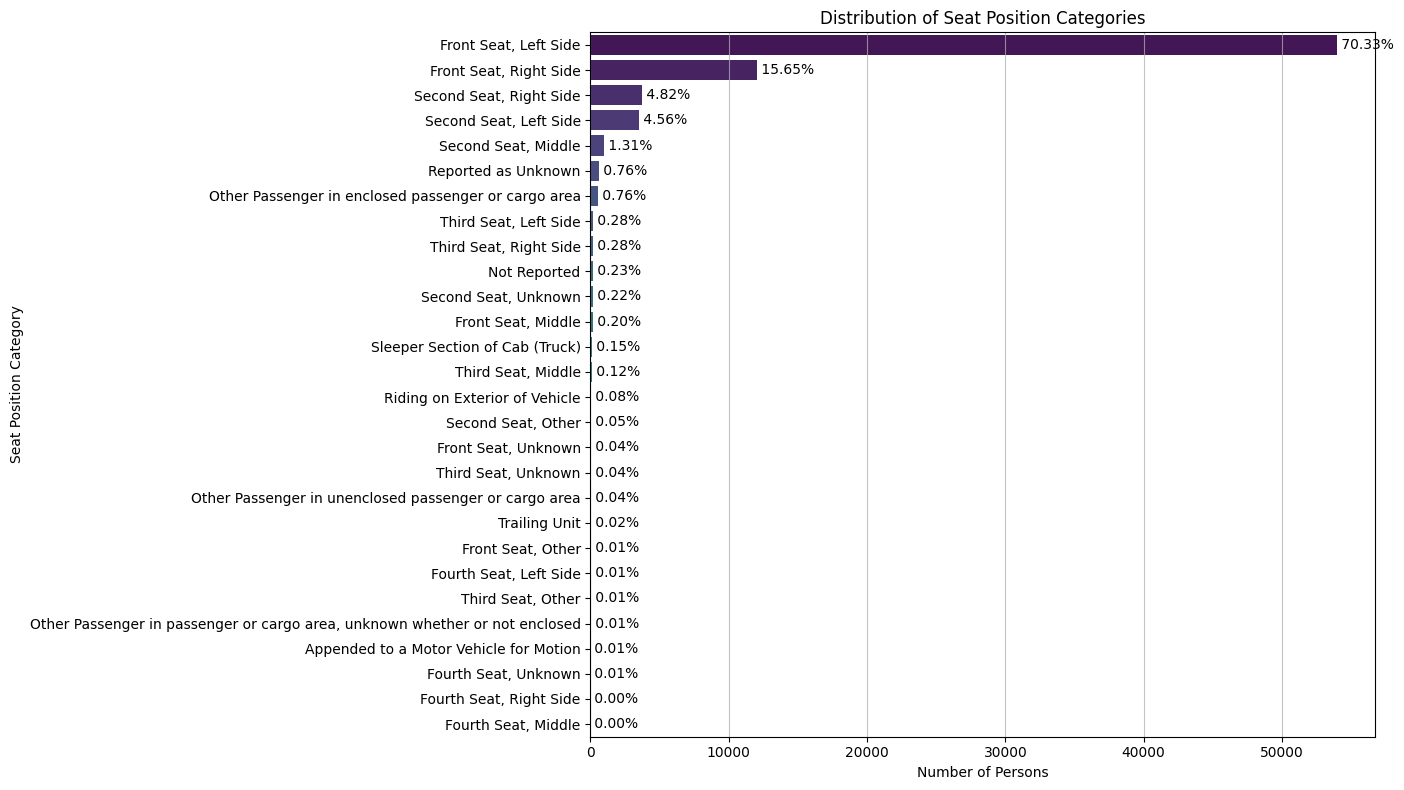

In [ ]:
# Calculate value counts and percentages for 'SEAT_POSNAME'
seat_pos_category_counts = df_categorized_restraints_revised['SEAT_POSNAME'].value_counts()
seat_pos_category_percentages = (df_categorized_restraints_revised['SEAT_POSNAME'].value_counts(normalize=True) * 100).round(2)

# Combine into a summary DataFrame
seat_pos_summary = pd.DataFrame({
    'Count': seat_pos_category_counts,
    'Percentage': seat_pos_category_percentages
})

print("Summary of Seat Position Categories:")
display(seat_pos_summary)

# Plotting the distribution of 'SEAT_POSNAME' categories
plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y=seat_pos_summary.index, data=seat_pos_summary, palette='viridis', hue=seat_pos_summary.index, legend=False)
plt.title('Distribution of Seat Position Categories')
plt.xlabel('Number of Persons')
plt.ylabel('Seat Position Category')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in seat_pos_summary.iterrows():
    plt.text(row['Count'], index, f' {row['Percentage']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Fatality Rates by Seat Position

Fatality Rates by Seat Position:


,SEAT_POSNAME,Total_Persons,Fatalities,Fatality Rate (%)
0,Appended to a Motor Vehicle for Motion,7,7,100.00
15,Riding on Exterior of Vehicle,61,59,96.72
24,"Third Seat, Other",9,8,88.89
14,Reported as Unknown,587,505,86.03
27,Trailing Unit,15,12,80.00
13,Other Passenger in unenclosed passenger or car...,27,20,74.07
3,"Fourth Seat, Right Side",3,2,66.67
1,"Fourth Seat, Left Side",9,6,66.67
20,"Second Seat, Unknown",167,111,66.47
9,"Front Seat, Unknown",31,20,64.52


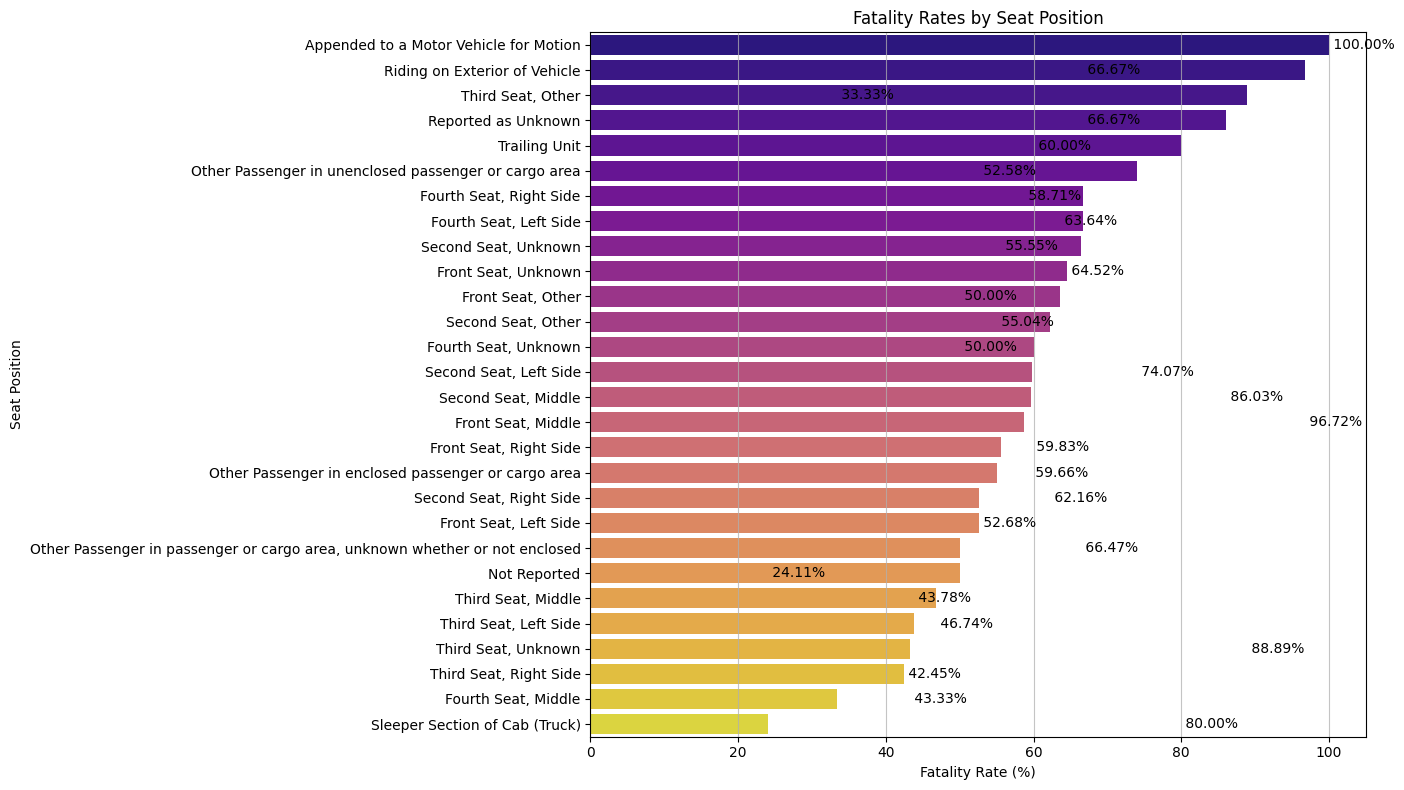

In [ ]:
# Filter out 'Not Applicable' and 'Unknown' seat positions for meaningful rate calculation
df_seat_pos_filtered = df_categorized_restraints_revised[
    ~df_categorized_restraints_revised['SEAT_POSNAME'].isin(['Not Applicable', 'Unknown'])
].copy()

# Calculate total persons for each seat position
total_persons_by_seat_pos = df_seat_pos_filtered.groupby('SEAT_POSNAME').size().reset_index(name='Total_Persons')

# Calculate total fatalities for each seat position
fatalities_by_seat_pos = df_seat_pos_filtered[df_seat_pos_filtered['FATALITY_TYPE'] == 'FATAL'].groupby('SEAT_POSNAME').size().reset_index(name='Fatalities')

# Merge the two DataFrames
merged_seat_pos_data = pd.merge(total_persons_by_seat_pos, fatalities_by_seat_pos, on='SEAT_POSNAME', how='left')

# Fill NaN values in 'Fatalities' with 0 (for combinations with no fatalities)
merged_seat_pos_data['Fatalities'] = merged_seat_pos_data['Fatalities'].fillna(0).astype(int)

# Calculate Fatality Rate
merged_seat_pos_data['Fatality Rate (%)'] = (merged_seat_pos_data['Fatalities'] / merged_seat_pos_data['Total_Persons'] * 100).round(2)

# Sort by Fatality Rate for better insights
merged_seat_pos_data_sorted = merged_seat_pos_data.sort_values(by='Fatality Rate (%)', ascending=False)

print("Fatality Rates by Seat Position:")
display(merged_seat_pos_data_sorted)

# Plotting the fatality rates by seat position
plt.figure(figsize=(14, 8))
sns.barplot(x='Fatality Rate (%)', y='SEAT_POSNAME', data=merged_seat_pos_data_sorted, palette='plasma', hue='SEAT_POSNAME', legend=False)
plt.title('Fatality Rates by Seat Position')
plt.xlabel('Fatality Rate (%)')
plt.ylabel('Seat Position')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in merged_seat_pos_data_sorted.iterrows():
    plt.text(row['Fatality Rate (%)'], index, f' {row['Fatality Rate (%)']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Fatality Rates for Specific Passenger Seat Positions

To focus on the common passenger seat positions you highlighted, I will categorize the `SEAT_POSNAME` into:
*   `Front Seat, Left Side`
*   `Front Seat, Right Side`
*   `Second Seat, Left Side`
*   `Second Seat, Right Side`
*   All other positions will be grouped into an `Other Passenger Position` category.

In [ ]:
# Define the mapping for specific passenger seat positions
def categorize_specific_seat_pos(seat_pos_name):
    if seat_pos_name == 'Front Seat, Left Side':
        return 'Front Seat, Left Side'
    elif seat_pos_name == 'Front Seat, Right Side':
        return 'Front Seat, Right Side'
    elif seat_pos_name == 'Second Seat, Left Side':
        return 'Second Seat, Left Side'
    elif seat_pos_name == 'Second Seat, Right Side':
        return 'Second Seat, Right Side'
    else:
        return 'Other Passenger Position'

# Apply the new categorization to the filtered DataFrame
df_seat_pos_filtered.loc[:, 'Specific_Seat_Position'] = df_seat_pos_filtered['SEAT_POSNAME'].apply(categorize_specific_seat_pos)

# Calculate total persons for each specific seat position
total_persons_by_specific_seat = df_seat_pos_filtered.groupby('Specific_Seat_Position').size().reset_index(name='Total_Persons')

# Calculate total fatalities for each specific seat position
fatalities_by_specific_seat = df_seat_pos_filtered[df_seat_pos_filtered['FATALITY_TYPE'] == 'FATAL'].groupby('Specific_Seat_Position').size().reset_index(name='Fatalities')

# Merge the two DataFrames
merged_specific_seat_data = pd.merge(total_persons_by_specific_seat, fatalities_by_specific_seat, on='Specific_Seat_Position', how='left')

# Fill NaN values in 'Fatalities' with 0
merged_specific_seat_data['Fatalities'] = merged_specific_seat_data['Fatalities'].fillna(0).astype(int)

# Calculate Fatality Rate
merged_specific_seat_data['Fatality Rate (%)'] = (merged_specific_seat_data['Fatalities'] / merged_specific_seat_data['Total_Persons'] * 100).round(2)

# Sort by Fatality Rate for better insights
merged_specific_seat_data_sorted = merged_specific_seat_data.sort_values(by='Fatality Rate (%)', ascending=False)

print("Fatality Rates by Specific Passenger Seat Position:")
display(merged_specific_seat_data_sorted)

Fatality Rates by Specific Passenger Seat Position:


,Specific_Seat_Position,Total_Persons,Fatalities,Fatality Rate (%)
2,Other Passenger Position,3565,2157,60.50
3,"Second Seat, Left Side",3500,2094,59.83
1,"Front Seat, Right Side",12019,6677,55.55
4,"Second Seat, Right Side",3698,1948,52.68
0,"Front Seat, Left Side",54013,28401,52.58


### Visualization of Fatality Rates by Specific Passenger Seat Position

This bar plot illustrates the fatality rates for the explicitly grouped common passenger seat positions and all other positions combined.

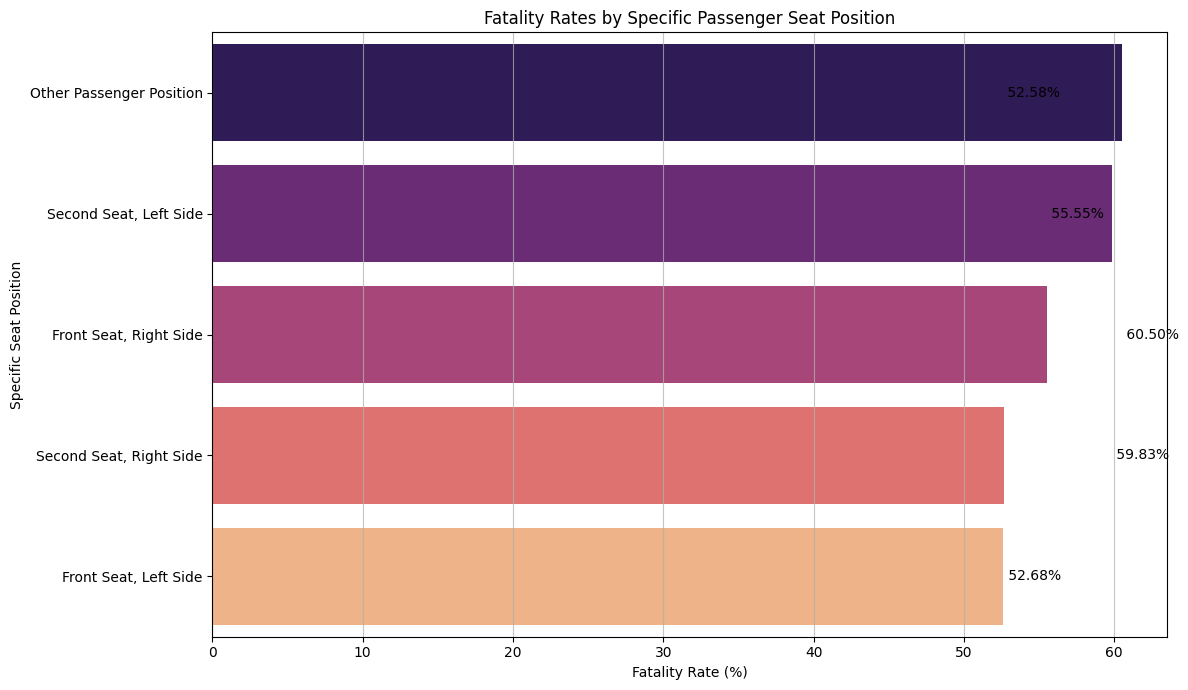

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Fatality Rate (%)', y='Specific_Seat_Position', data=merged_specific_seat_data_sorted, palette='magma', hue='Specific_Seat_Position', legend=False)
plt.title('Fatality Rates by Specific Passenger Seat Position')
plt.xlabel('Fatality Rate (%)')
plt.ylabel('Specific Seat Position')
plt.grid(axis='x', alpha=0.75)

# Add percentage labels to the bars
for index, row in merged_specific_seat_data_sorted.iterrows():
    plt.text(row['Fatality Rate (%)'], index, f' {row['Fatality Rate (%)']:.2f}%', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

### Fatality Rates by Specific Passenger Seat Position and Age Group

Let's delve deeper into the impact of seat position by analyzing fatality rates across different age groups. This will help identify which age demographics are most vulnerable in specific seating arrangements.

In [ ]:
import numpy as np

# Calculate total persons for each age group and specific seat position
total_persons_age_seat_pos = df_seat_pos_filtered.groupby(['Custom_Age_Group', 'Specific_Seat_Position'], observed=True).size().reset_index(name='Total_Persons')

# Calculate total fatalities for each age group and specific seat position
fatalities_age_seat_pos = df_seat_pos_filtered[df_seat_pos_filtered['FATALITY_TYPE'] == 'FATAL'].groupby(['Custom_Age_Group', 'Specific_Seat_Position'], observed=True).size().reset_index(name='Fatalities')

# Merge the two DataFrames
merged_age_seat_pos_data = pd.merge(total_persons_age_seat_pos, fatalities_age_seat_pos, on=['Custom_Age_Group', 'Specific_Seat_Position'], how='left')

# Fill NaN values in 'Fatalities' with 0 (for combinations with no fatalities)
merged_age_seat_pos_data['Fatalities'] = merged_age_seat_pos_data['Fatalities'].fillna(0).astype(int)

# Calculate Fatality Rate
merged_age_seat_pos_data['Fatality Rate (%)'] = (merged_age_seat_pos_data['Fatalities'] / merged_age_seat_pos_data['Total_Persons'] * 100).round(2)

# Sort for better readability (optional)
merged_age_seat_pos_data_sorted = merged_age_seat_pos_data.sort_values(by=['Custom_Age_Group', 'Fatality Rate (%)'], ascending=[True, False])

print("Fatality Rates by Age Group and Specific Passenger Seat Position:")
display(merged_age_seat_pos_data_sorted)

Fatality Rates by Age Group and Specific Passenger Seat Position:


,Custom_Age_Group,Specific_Seat_Position,Total_Persons,Fatalities,Fatality Rate (%)
0,Children (0-12),"Front Seat, Left Side",28,26,92.86
2,Children (0-12),Other Passenger Position,1226,625,50.98
3,Children (0-12),"Second Seat, Left Side",1164,512,43.99
1,Children (0-12),"Front Seat, Right Side",456,200,43.86
4,Children (0-12),"Second Seat, Right Side",1394,581,41.68
7,Teens (13-19),Other Passenger Position,710,468,65.92
8,Teens (13-19),"Second Seat, Left Side",728,442,60.71
9,Teens (13-19),"Second Seat, Right Side",818,483,59.05
5,Teens (13-19),"Front Seat, Left Side",3747,2135,56.98
6,Teens (13-19),"Front Seat, Right Side",2002,1064,53.15


### Visualization of Fatality Rates by Specific Passenger Seat Position and Age Group

This grouped bar plot will allow for a visual comparison of fatality rates across different seat positions within each age group, and also highlight how fatality rates for a given seat position change across age groups.

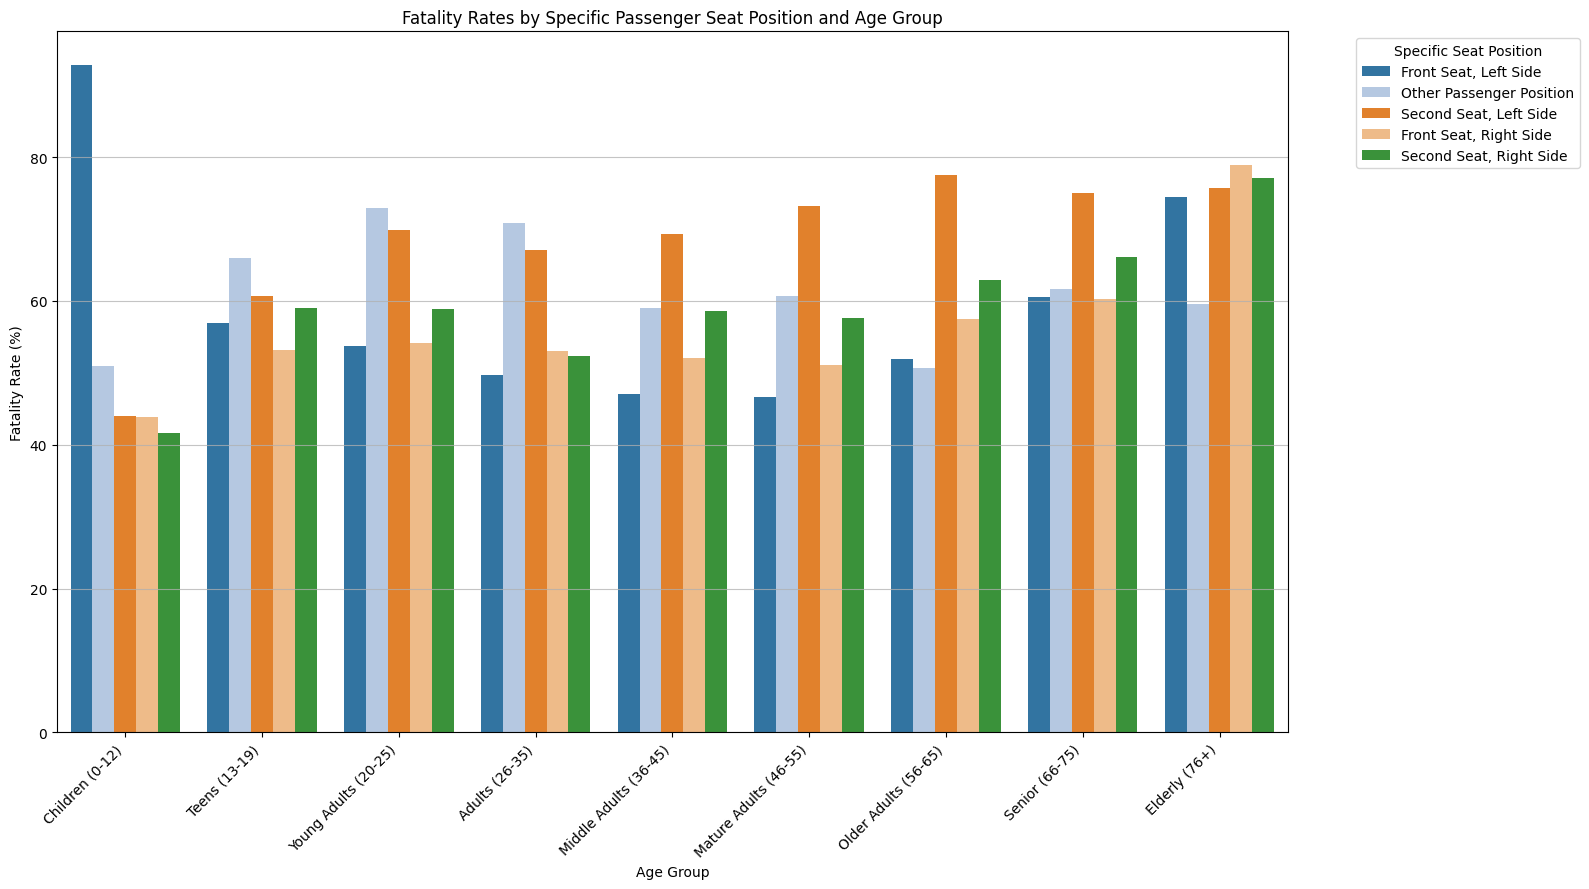

In [ ]:
plt.figure(figsize=(16, 9))
sns.barplot(
    x='Custom_Age_Group',
    y='Fatality Rate (%)',
    hue='Specific_Seat_Position',
    data=merged_age_seat_pos_data_sorted,
    palette='tab20'
)
plt.title('Fatality Rates by Specific Passenger Seat Position and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Fatality Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Specific Seat Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Heatmap of Child Fatalities by Sub-Age Group and Specific Seat Position

This heatmap provides a visual representation of the number of child fatalities across various sub-age groups and specific passenger seat positions. This granular view can help pinpoint the most dangerous combinations for children.

Child Fatalities by Sub-Age Group and Specific Seat Position:


Specific_Seat_Position,"Front Seat, Left Side","Front Seat, Right Side","Second Seat, Left Side","Second Seat, Right Side",Other Passenger Position
Children_Sub_Age_Group,,,,,
Infants (0-1),0,7,98,116,85
Toddlers (2-3),1,7,71,113,95
Preschoolers (4-5),1,10,97,90,157
Young Children (6-9),6,64,157,165,173
Pre-Teens (10-12),18,112,89,97,115


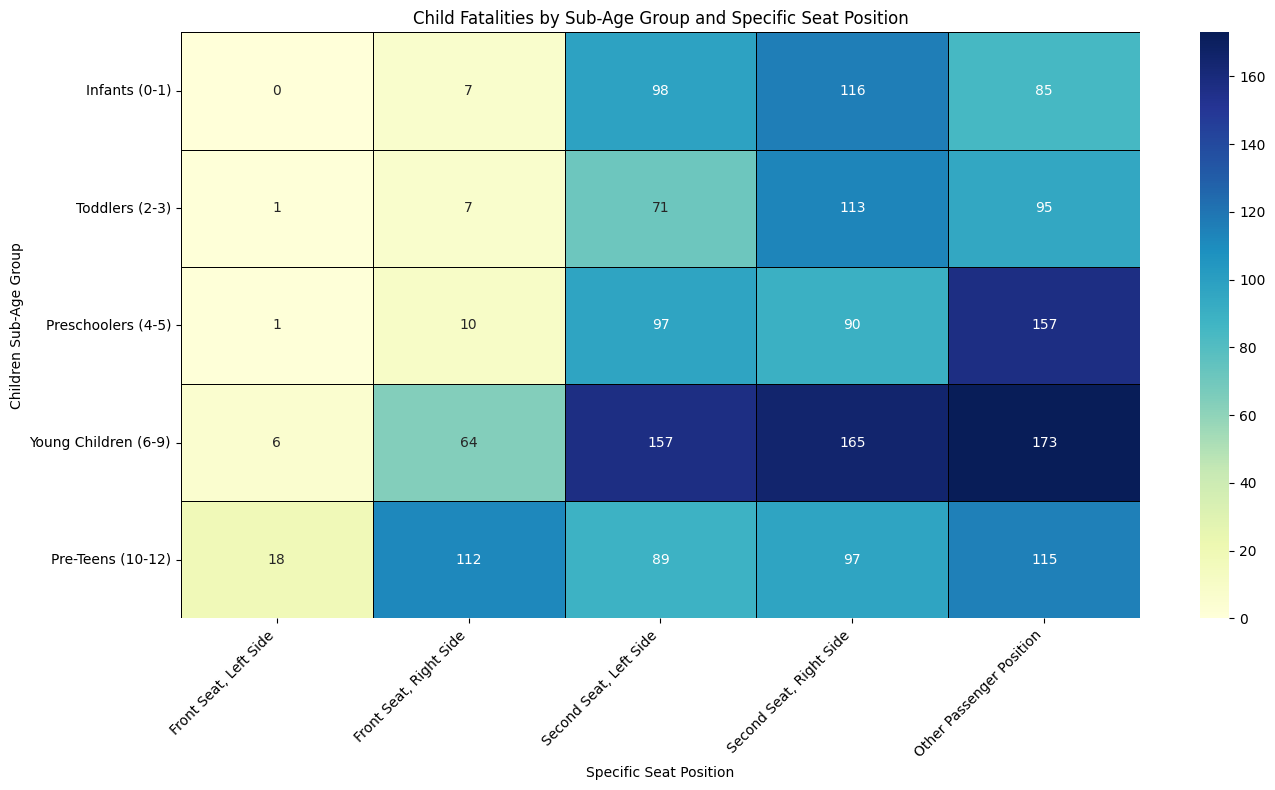

In [ ]:
# Filter for fatal cases within the 'Children (0-12)' age group
df_children_fatal_seat_pos = df_categorized_restraints_revised[
    (df_categorized_restraints_revised['Custom_Age_Group'] == 'Children (0-12)') &
    (df_categorized_restraints_revised['FATALITY_TYPE'] == 'FATAL')
].copy()

# Define custom bins and labels for children subgroups (reusing definitions from earlier)
children_custom_bins = [0, 2, 4, 6, 10, 13] # Age ranges: [0,2), [2,4), [4,6), [6,10), [10,13)
children_custom_labels = [
    'Infants (0-1)',
    'Toddlers (2-3)',
    'Preschoolers (4-5)',
    'Young Children (6-9)',
    'Pre-Teens (10-12)'
]

# Create a new column 'Children_Sub_Age_Group' within the filtered DataFrame
df_children_fatal_seat_pos.loc[:, 'Children_Sub_Age_Group'] = pd.cut(
    df_children_fatal_seat_pos['AGE'],
    bins=children_custom_bins,
    labels=children_custom_labels,
    right=False,
    ordered=True
)

# Define the mapping for specific passenger seat positions (reusing definition from earlier)
def categorize_specific_seat_pos(seat_pos_name):
    if seat_pos_name == 'Front Seat, Left Side':
        return 'Front Seat, Left Side'
    elif seat_pos_name == 'Front Seat, Right Side':
        return 'Front Seat, Right Side'
    elif seat_pos_name == 'Second Seat, Left Side':
        return 'Second Seat, Left Side'
    elif seat_pos_name == 'Second Seat, Right Side':
        return 'Second Seat, Right Side'
    else:
        return 'Other Passenger Position'

# Apply the new categorization to the filtered DataFrame for seat positions
df_children_fatal_seat_pos.loc[:, 'Specific_Seat_Position'] = df_children_fatal_seat_pos['SEAT_POSNAME'].apply(categorize_specific_seat_pos)

# Filter out 'Not Applicable' and 'Unknown' from 'Specific_Seat_Position' if any were created due to 'SEAT_POSNAME' mapping to 'Other'
df_children_fatal_seat_pos = df_children_fatal_seat_pos[
    ~df_children_fatal_seat_pos['Specific_Seat_Position'].isin(['Not Applicable', 'Unknown'])
].copy()

# Create a pivot table for the heatmap
heatmap_children_seat_pos_data = df_children_fatal_seat_pos.pivot_table(
    index='Children_Sub_Age_Group',
    columns='Specific_Seat_Position',
    values='FATALITY_TYPE', # Using FATALITY_TYPE to count fatal occurrences
    aggfunc='count', # Count the number of fatal cases
    fill_value=0, # Fill NaN with 0 for combinations with no fatalities
    observed=True
)

# Reorder columns for better readability if needed
ordered_seat_positions = [
    'Front Seat, Left Side',
    'Front Seat, Right Side',
    'Second Seat, Left Side',
    'Second Seat, Right Side',
    'Other Passenger Position'
]
heatmap_children_seat_pos_data = heatmap_children_seat_pos_data.reindex(columns=ordered_seat_positions)

print("Child Fatalities by Sub-Age Group and Specific Seat Position:")
display(heatmap_children_seat_pos_data)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_children_seat_pos_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5, linecolor='black')
plt.title('Child Fatalities by Sub-Age Group and Specific Seat Position')
plt.xlabel('Specific Seat Position')
plt.ylabel('Children Sub-Age Group')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

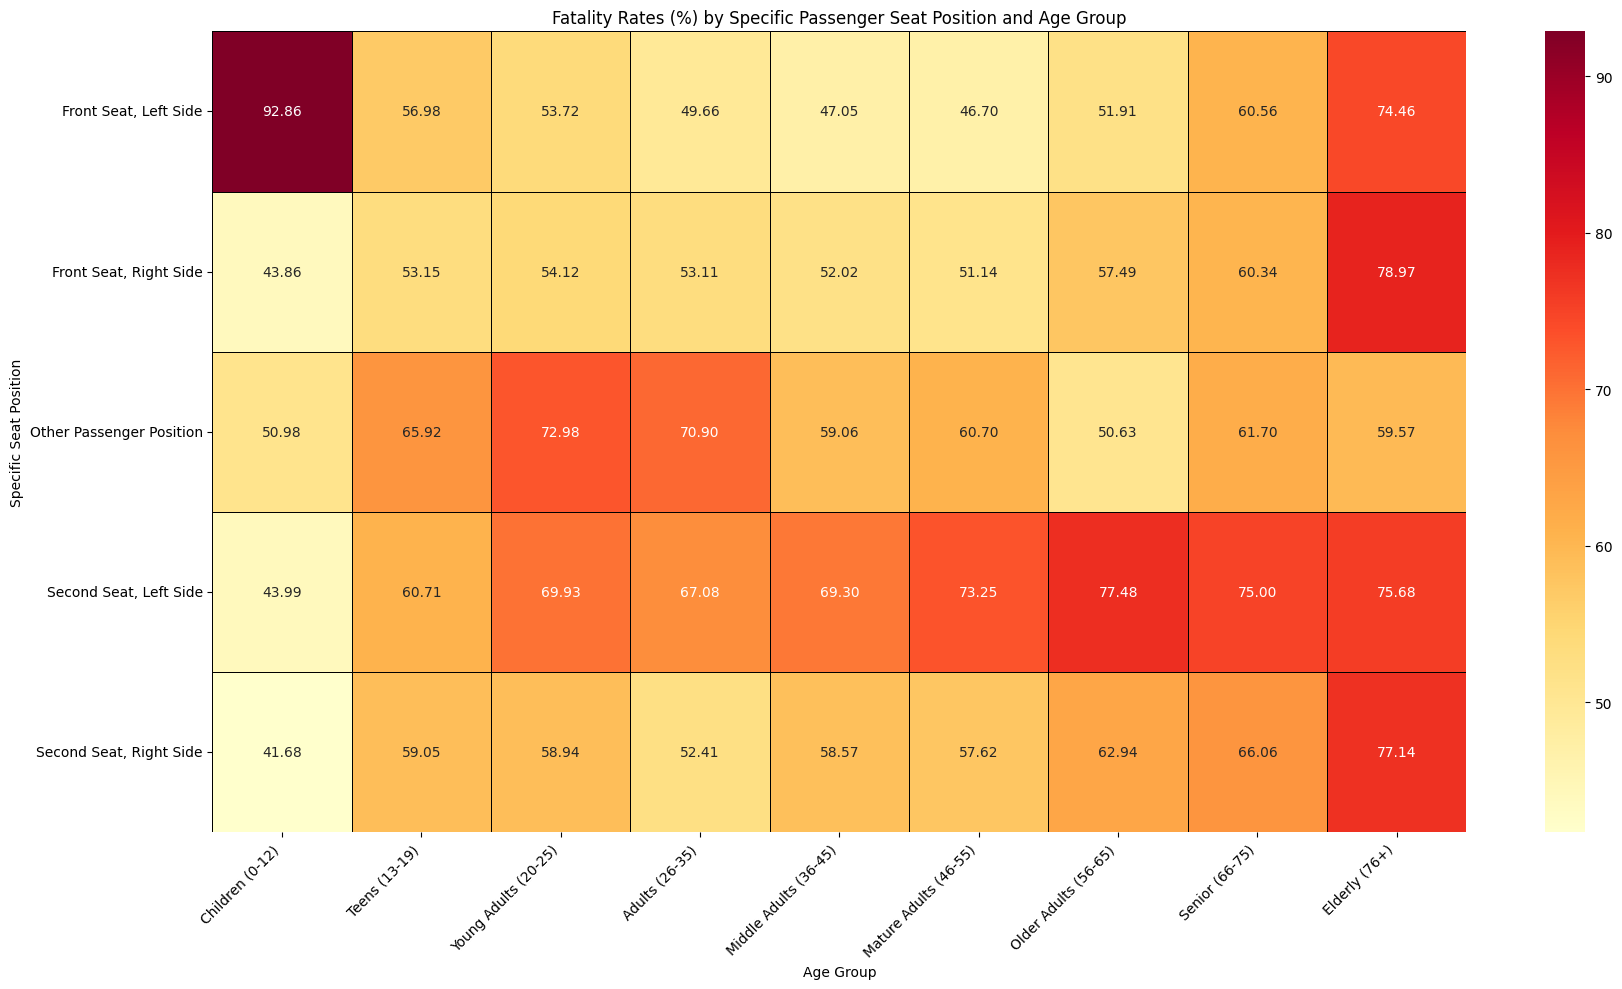

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for the heatmap
heatmap_data = merged_age_seat_pos_data.pivot_table(
    index='Specific_Seat_Position',
    columns='Custom_Age_Group',
    values='Fatality Rate (%)',
    observed=True
)

# Sort the columns (age groups) to ensure correct order
ordered_age_groups = [
    'Children (0-12)',
    'Teens (13-19)',
    'Young Adults (20-25)',
    'Adults (26-35)',
    'Middle Adults (36-45)',
    'Mature Adults (46-55)',
    'Older Adults (56-65)',
    'Senior (66-75)',
    'Elderly (76+)'
]
heatmap_data = heatmap_data[ordered_age_groups]

plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=.5, linecolor='black')
plt.title('Fatality Rates (%) by Specific Passenger Seat Position and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Specific Seat Position')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()